# Taller 1 — Machine Learning Applied
## Parte A — Regresión: *Uber Ride Price Prediction*

**Curso:** Machine Learning Applied
**Integrantes:** Equipo 3 — Jorge Andrés Durán y Juan Miguel Castro
**Fecha:** 2026

---

### Objetivo del notebook

Aplicar el ciclo completo de un proyecto de Machine Learning supervisado de **regresión** sobre el dataset
*Uber Ride Price Prediction*: EDA y limpieza, ingeniería de características, partición train/validation/test,
construcción de `Pipeline` + `ColumnTransformer` sin fuga de datos, entrenamiento y comparación de
**KNN Regressor**, **Ridge** y **Lasso**, detección de overfitting/underfitting, evaluación honesta en test,
validación cruzada con `RandomizedSearchCV` y predicción sobre una observación inventada.

### Mapa del notebook

| Fase | Contenido | Puntos del taller |
|---|---|---|
| 1 | EDA, limpieza y preprocesamiento | 1 – 10 |
| 2 | División de datos y Pipelines | 11 – 13 |
| 3 | Modelado: KNN, Ridge, Lasso | 14 – 15 |
| 5 | Métricas en train y validación (over/underfitting) | 18, 20, 21 |
| 6 | Evaluación final en Test | 22 – 23 |
| 7 | Cross Validation y optimización de hiperparámetros | 24 – 25, 27 |
| 8 | Predicción sobre muestra inventada | 28 |
| 9 | Conclusiones + subplot (2,2) | 29 |

> **Nota de reproducibilidad:** todas las particiones y búsquedas usan `RANDOM_STATE = 42`.

## 0. Configuración del entorno

Se fija la semilla global, se define una paleta de color **validada para daltonismo** (separación ΔE ≥ 8 en
deuteranopía entre pares adyacentes) y se estandarizan los parámetros de las figuras para que todas las gráficas
del notebook se lean como un mismo sistema visual.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from scipy.stats import randint, loguniform

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paleta categórica validada (colorblind-safe) + grises de tinta
PALETA = ["#2563EB", "#D97706", "#0D9488", "#BE123C", "#7C3AED"]
TINTA, TINTA_SUAVE, REJILLA = "#1F2328", "#57606A", "#D8DEE4"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": REJILLA, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.8, "grid.alpha": 0.7,
    "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.labelsize": 10, "axes.labelcolor": TINTA_SUAVE,
    "xtick.color": TINTA_SUAVE, "ytick.color": TINTA_SUAVE,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "font.size": 10,
})

print("Entorno listo · numpy", np.__version__, "· pandas", pd.__version__)

Entorno listo · numpy 2.4.4 · pandas 3.0.2


---
# FASE 1 — EDA, limpieza y preprocesamiento

## 1. Contexto de negocio y variable objetivo

**El problema.** Uber (como cualquier plataforma de *ride-hailing*) necesita mostrarle al usuario un **precio
estimado antes** de que confirme el viaje. Ese precio se calcula en milisegundos a partir de información
disponible *en el momento de la solicitud*: dónde está el pasajero, a dónde va, cuántos van y en qué momento
del día/semana/año se pide el viaje. Un estimador mal calibrado tiene costo directo en el negocio:

- **Subestimar** la tarifa → el usuario paga más de lo mostrado → reclamos, reembolsos y pérdida de confianza.
- **Sobreestimar** la tarifa → el usuario abandona la solicitud → pérdida de viajes frente a la competencia.

**Variable objetivo (target).** `fare_amount`: el valor de la tarifa del viaje en **dólares estadounidenses (USD)**.
Es una variable **numérica continua y positiva**, por lo tanto estamos frente a un problema de **regresión
supervisada**.

**Variables predictoras disponibles.** Coordenadas geográficas de recogida y destino, marca de tiempo de la
recogida y número de pasajeros. Nótese que el dataset **no** trae directamente la distancia ni la duración del
viaje: esa información está *implícita* en las coordenadas y tendrá que construirse (ver punto 6b).

**Aclaración importante sobre el alcance.** El dataset corresponde a viajes de taxi/Uber en la ciudad de
**Nueva York** entre 2009 y 2015. Cualquier conclusión aplica a ese contexto tarifario (tarifa base + recargo
por distancia/tiempo, tarifa plana a aeropuertos, peajes) y no debería extrapolarse a otras ciudades.

## 2. Carga del dataset, primeras filas y estructura

Se carga con `pandas`. La celda busca el archivo en varias rutas comunes para que el notebook corra igual en
local, en Colab (archivo subido a `/content`) o desde Google Drive.

In [2]:
RUTAS_CANDIDATAS = [
    "uber.csv", "data/uber.csv", "../data/uber.csv",
    "/content/uber.csv", "/content/drive/MyDrive/uber.csv",
]
ruta = next((p for p in RUTAS_CANDIDATAS if os.path.exists(p)), None)
if ruta is None:
    raise FileNotFoundError(
        "No se encontró 'uber.csv'. Súbelo a la misma carpeta del notebook "
        "(en Colab: panel izquierdo > Archivos > Subir) o agrega su ruta a RUTAS_CANDIDATAS."
    )

df_raw = pd.read_csv(ruta)
print("Archivo cargado desde:", ruta)
print("Dimensiones (filas, columnas):", df_raw.shape)
df_raw.head()

Archivo cargado desde: uber.csv
Dimensiones (filas, columnas): (200000, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,52:06.0,7.5000,2015-05-07 19:52:06 UTC,-73.9998,40.7384,-73.9995,40.7232,1
1,27835199,04:56.0,7.7000,2009-07-17 20:04:56 UTC,-73.9944,40.7282,-73.9947,40.7503,1
2,44984355,45:00.0,12.9000,2009-08-24 21:45:00 UTC,-74.0050,40.7408,-73.9626,40.7726,1
3,25894730,22:21.0,5.3000,2009-06-26 08:22:21 UTC,-73.9761,40.7908,-73.9653,40.8033,3
4,17610152,47:00.0,16.0000,2014-08-28 17:47:00 UTC,-73.9250,40.7441,-73.9731,40.7612,5


In [3]:
df_raw.tail()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
199995,42598914,49:00.0,3.0000,2012-10-28 10:49:00 UTC,-73.9870,40.7394,-73.9865,40.7403,1
199996,16382965,09:00.0,7.5000,2014-03-14 01:09:00 UTC,-73.9847,40.7368,-74.0067,40.7396,1
199997,27804658,42:00.0,30.9000,2009-06-29 00:42:00 UTC,-73.9860,40.7565,-73.8590,40.6926,2
199998,20259894,56:25.0,14.5000,2015-05-20 14:56:25 UTC,-73.9971,40.7255,-73.9832,40.6954,1
199999,11951496,08:00.0,14.1000,2010-05-15 04:08:00 UTC,-73.9844,40.7201,-73.9855,40.7688,1


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


### Diccionario de datos

| Columna | Tipo esperado | Significado | ¿Se usa como predictor? |
|---|---|---|---|
| `Unnamed: 0` | entero | Índice residual del archivo original (número de fila del CSV fuente). | **No** — identificador, sin información del fenómeno. |
| `key` | texto | Clave única del registro. En este archivo viene truncada (`52:06.0`), es un fragmento de la marca de tiempo. | **No** — identificador redundante con `pickup_datetime`. |
| `fare_amount` | flotante | **TARGET.** Tarifa del viaje en USD. | Es la variable a predecir. |
| `pickup_datetime` | fecha-hora (UTC) | Momento en que se inicia el viaje. | Sí, como fuente de variables temporales derivadas. |
| `pickup_longitude` | flotante | Longitud del punto de recogida (grados decimales). | Sí. |
| `pickup_latitude` | flotante | Latitud del punto de recogida. | Sí. |
| `dropoff_longitude` | flotante | Longitud del punto de destino. | Sí. |
| `dropoff_latitude` | flotante | Latitud del punto de destino. | Sí. |
| `passenger_count` | entero | Número de pasajeros declarados. | Sí. |

**Observación temprana sobre el tipo de dato:** `pickup_datetime` llega como `object` (texto), no como
`datetime64`. Mientras siga siendo texto no se pueden extraer hora, día de la semana ni año, así que su
conversión es el primer arreglo de formato del punto 6.

## 3. Estadísticos descriptivos e interpretación

`describe()` sobre las columnas numéricas. Lo interesante aquí no es la tabla, sino **qué valores son
físicamente imposibles**: son el mapa de lo que hay que limpiar.

In [5]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"200,000.0000","27,712,503.6823","16,013,822.2128",1.0000,"13,825,346.2500","27,745,495.0000","41,555,300.7500","55,423,567.0000"
fare_amount,"200,000.0000",11.3600,9.9018,-52.0000,6.0000,8.5000,12.5000,499.0000
pickup_longitude,"200,000.0000",-72.5276,11.4378,"-1,340.6484",-73.9921,-73.9818,-73.9672,57.4185
pickup_latitude,"200,000.0000",39.9359,7.7205,-74.0155,40.7348,40.7526,40.7672,"1,644.4215"
dropoff_longitude,"199,999.0000",-72.5253,13.1174,"-3,356.6663",-73.9914,-73.9801,-73.9637,"1,153.5726"
dropoff_latitude,"199,999.0000",39.9239,6.7948,-881.9855,40.7338,40.7530,40.7680,872.6976
passenger_count,"200,000.0000",1.6845,1.3860,0.0000,1.0000,1.0000,2.0000,208.0000


### Interpretación de los estadísticos (3+ lecturas en términos del negocio)

1. **`fare_amount` — media 11.36 USD, mediana 8.50 USD, máximo 499 USD, mínimo negativo.**
   La media es ~34 % mayor que la mediana: la distribución de tarifas está **sesgada a la derecha**, lo cual es
   exactamente lo que se espera del negocio — la mayoría son carreras cortas dentro de Manhattan y una cola
   larga de viajes a aeropuertos o fuera de la ciudad. El detalle crítico es el **mínimo negativo**: una tarifa
   negativa no existe (son reversos contables o errores de captura) y el **máximo de 499 USD** está muy por
   encima de lo que cuesta cualquier carrera urbana razonable en NYC. Ambos extremos contaminan cualquier
   modelo que minimice error cuadrático.

2. **`pickup_latitude` con máximo 1 644 y `dropoff_longitude` con máximo 1 154.**
   La latitud sólo puede vivir en [-90, 90] y la longitud en [-180, 180]. Valores fuera de ese rango son
   **errores de GPS o de captura**, no viajes raros. Además, los cuartiles (lon ≈ -73.99, lat ≈ 40.75)
   confirman que el grueso de los datos está efectivamente sobre Manhattan; lo que se salga de un rectángulo
   alrededor del área metropolitana de Nueva York no es un viaje de este servicio.

3. **`passenger_count` — media 1.68, mediana 1, máximo 208 y mínimo 0.**
   El pasajero típico viaja **solo** (la mediana es 1), coherente con el uso real de Uber. Pero un viaje con
   **208 pasajeros** es imposible en un vehículo, y **0 pasajeros** tampoco describe un viaje facturado: son
   valores centinela/errores. El máximo legal razonable en la flota (UberXL / van) es **6**.

4. *(Bonus)* **`Unnamed: 0` tiene media 27 712 500 y máximo 55 millones**, mientras el dataset tiene 200 000
   filas: confirma que es un índice heredado de un archivo mucho más grande (muestreo), es decir, un
   identificador y no una medición.

## 4. Valores nulos: conteo, porcentaje y estrategia

Se cuantifican los nulos por columna en número y en porcentaje sobre el total de filas.

In [6]:
nulos = pd.DataFrame({
    "nulos": df_raw.isna().sum(),
    "% nulos": (df_raw.isna().mean() * 100).round(6),
    "dtype": df_raw.dtypes.astype(str),
})
nulos.sort_values("nulos", ascending=False)

,nulos,% nulos,dtype
dropoff_latitude,1,0.0005,float64
dropoff_longitude,1,0.0005,float64
Unnamed: 0,0,0.0000,int64
key,0,0.0000,str
fare_amount,0,0.0000,float64
pickup_longitude,0,0.0000,float64
pickup_datetime,0,0.0000,str
pickup_latitude,0,0.0000,float64
passenger_count,0,0.0000,int64


In [7]:
# ¿Los nulos están en las mismas filas?
filas_nulas = df_raw[df_raw.isna().any(axis=1)]
print("Filas con al menos un nulo:", len(filas_nulas))
filas_nulas

Filas con al menos un nulo: 1


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,51:57.0,24.1000,2013-07-02 03:51:57 UTC,-73.9506,40.7797,NaN,NaN,0


### Justificación de la estrategia frente a los nulos

El dataset está **casi completo**: sólo `dropoff_longitude` y `dropoff_latitude` tienen valores faltantes, y
ambos corresponden a **la misma fila** — es decir, **1 fila de 200 000 (0.0005 %)**.

**Decisión: eliminar esa fila (`dropna`).** Justificación:

- **Por el porcentaje:** con 0.0005 % de registros afectados, eliminar la fila no cambia ninguna distribución ni
  introduce sesgo de selección; sí lo haría si habláramos de un 5–10 %.
- **Por el tipo de variable:** son **coordenadas geográficas**. Imputar la **media** de la longitud/latitud de
  destino colocaría el viaje en un punto geográfico arbitrario (el "centroide" de Nueva York), inventando un
  destino que nunca ocurrió y, peor aún, **falsificando la distancia recorrida**, que es justamente el predictor
  más fuerte del precio. Imputar con la **moda** tiene el mismo problema y encima crea un punto artificialmente
  repetido que distorsiona a KNN. Para coordenadas no existe una imputación "neutra".
- **Por qué no eliminar la columna:** el destino es información esencial del problema; eliminar la columna
  destruiría el 100 % de la señal para ahorrar 1 fila.

**Nota de ingeniería (importante para la Fase 2):** aunque aquí la eliminación resuelve el caso, el
`ColumnTransformer` de la Fase 2 **sí incluirá un `SimpleImputer`**. No es redundante: en producción el modelo
recibirá registros nuevos que pueden llegar con campos faltantes, y el pipeline debe saber qué hacer con ellos
sin caerse. El imputador se ajusta sólo sobre train (mediana), de modo que es una salvaguarda, no una fuga.

In [8]:
df = df_raw.dropna().copy()
print(f"Filas antes: {len(df_raw):,}  |  después de dropna(): {len(df):,}  |  eliminadas: {len(df_raw) - len(df):,}")

Filas antes: 200,000  |  después de dropna(): 199,999  |  eliminadas: 1


## 5. Duplicados

Se revisan duplicados exactos (toda la fila) y duplicados "de negocio": mismo origen, destino, momento y número
de pasajeros — que representarían el mismo viaje cargado dos veces aunque el índice heredado difiera.

In [9]:
dups_exactos = df.duplicated().sum()
claves_viaje = ["pickup_datetime", "pickup_longitude", "pickup_latitude",
                "dropoff_longitude", "dropoff_latitude", "passenger_count", "fare_amount"]
dups_negocio = df.duplicated(subset=claves_viaje).sum()

print(f"Duplicados exactos (todas las columnas): {dups_exactos:,}")
print(f"Duplicados de negocio (mismo viaje, ignorando índice y key): {dups_negocio:,}")

n_antes = len(df)
df = df.drop_duplicates(subset=claves_viaje).reset_index(drop=True)
print(f"Filas eliminadas por duplicado: {n_antes - len(df):,}  ->  quedan {len(df):,}")

Duplicados exactos (todas las columnas): 0
Duplicados de negocio (mismo viaje, ignorando índice y key): 0


Filas eliminadas por duplicado: 0  ->  quedan 199,999


### Justificación

No hay duplicados exactos (cada fila trae un `Unnamed: 0` distinto, así que la comparación fila-completa nunca
detectaría nada). Por eso la revisión correcta es sobre las **columnas que identifican el viaje**: si dos
registros comparten origen, destino, timestamp exacto al segundo, número de pasajeros y tarifa, se trata del
mismo evento cargado dos veces, no de dos viajes distintos.

**Decisión: eliminar los duplicados de negocio.** El motivo no es estético sino metodológico: un viaje repetido
puede quedar **una copia en train y otra en test**, y el modelo (sobre todo KNN, que memoriza vecinos) lo
"acertaría" trivialmente, **inflando artificialmente las métricas de test**. La cantidad es marginal frente al
tamaño del dataset, así que no hay pérdida de información relevante.

## 6. Inconsistencias de formato

Tres problemas de formato/consistencia detectados:

1. `pickup_datetime` es **texto**, no fecha.
2. `Unnamed: 0` y `key` son **identificadores** sin contenido predictivo (`key` además viene truncada y es
   redundante con `pickup_datetime`).
3. `passenger_count` contiene valores **fuera del dominio físico** (0 y 208).

In [10]:
print("Tipo original de pickup_datetime:", df["pickup_datetime"].dtype)
print("Ejemplos de 'key' (truncada e inservible):", df["key"].head(3).tolist())

# (1) Conversión a datetime (formato explícito: '2015-05-07 19:52:06 UTC')
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], format="%Y-%m-%d %H:%M:%S UTC", errors="coerce")
print("\nFechas que no se pudieron parsear:", int(df["pickup_datetime"].isna().sum()))
print("Rango temporal:", df["pickup_datetime"].min(), "->", df["pickup_datetime"].max())

# (2) Eliminación de identificadores
df = df.drop(columns=["Unnamed: 0", "key"])

# (3) Diagnóstico del dominio de passenger_count (todavía NO se filtra: se decide en el punto 7)
print("\nDistribución de passenger_count:")
print(df["passenger_count"].value_counts().sort_index())

Tipo original de pickup_datetime: str
Ejemplos de 'key' (truncada e inservible): ['52:06.0', '04:56.0', '45:00.0']



Fechas que no se pudieron parsear: 0
Rango temporal: 2009-01-01 01:15:22 -> 2015-06-30 23:40:39

Distribución de passenger_count:
passenger_count
0         708
1      138425
2       29428
3        8881
4        4276
5       14009
6        4271
208         1
Name: count, dtype: int64


### Justificación de las correcciones

- **`pickup_datetime` → `datetime64`.** Sin esta conversión no existe forma de extraer hora, día de la semana,
  mes o año, que son las variables que capturan la **estacionalidad de la demanda** (hora pico, fines de semana)
  y la **inflación tarifaria** entre 2009 y 2015. Se usa `format` explícito en lugar de inferencia automática
  porque es ~50× más rápido sobre 200 k filas y porque falla ruidosamente (`errors="coerce"` → `NaT`) si algún
  registro no cumple el formato, en vez de inventar una interpretación.
- **Eliminar `Unnamed: 0` y `key`.** Son identificadores. Dejarlos como predictores es peligroso: un índice
  correlacionado con el orden del archivo puede darle a un modelo lineal una pendiente espuria, y `key` sería
  una variable categórica de 200 000 niveles que haría explotar cualquier One-Hot. No se pierde información:
  `key` es un fragmento de `pickup_datetime`, que sí conservamos.
- **`passenger_count`:** no se toca todavía. Se documenta aquí y se trata junto con los demás valores fuera de
  dominio en el punto 7, para que toda la decisión de filtrado quede en un solo lugar y sea auditable.

*(No hay columnas de texto libre con problemas de mayúsculas/espacios en este dataset — todas las variables son
numéricas o temporales; las inconsistencias de etiquetas categóricas se tratan en detalle en el notebook de
clasificación, donde sí las hay.)*

## 6b. Ingeniería de características *(paso previo necesario al análisis de outliers)*

Este paso no está numerado en el enunciado pero es **indispensable**: el dataset entrega coordenadas crudas, y
ningún modelo lineal ni KNN puede deducir por sí solo que lo que determina el precio es la **distancia** entre
dos puntos de la Tierra (una relación no lineal entre cuatro columnas). Construimos:

| Variable creada | Cómo | Por qué importa para el precio |
|---|---|---|
| `distancia_km` | Fórmula de **Haversine** entre origen y destino | La tarifa de NYC es `base + tarifa/milla`; es el predictor dominante. |
| `hora`, `hora_sin`, `hora_cos` | De `pickup_datetime`; codificación **cíclica** | La hora es circular: 23:00 y 00:00 están a 1 h, no a 23 h. Sin sin/cos, KNN y los modelos lineales creerían que la medianoche es el punto más lejano del día. |
| `mes_sin`, `mes_cos` | Igual, sobre el mes | Estacionalidad (clima, turismo) sin imponer que diciembre y enero estén "lejos". |
| `anio` | Año del viaje | Captura la **inflación tarifaria** 2009–2015 (hubo aumentos de tarifa oficiales en NYC). |
| `dia_semana` | Nombre del día | Patrón laboral vs. fin de semana. |
| `franja_horaria` | Madrugada / Mañana / Tarde / Noche | Resumen interpretable de la demanda por bloques. |
| `es_fin_de_semana` | Sí/No | Demanda nocturna de ocio. |
| `es_aeropuerto` | Origen **o** destino a < 2 km de JFK, LGA o EWR | En NYC los viajes a JFK tienen **tarifa plana** (~52 USD) y a EWR llevan recargo: son un régimen de precio distinto que ningún modelo puede inferir sólo de la distancia. |

Nota: `hora` (entera) se conserva sólo para graficar; **no entra al modelo** para no duplicar la información ya
contenida en `hora_sin`/`hora_cos`.

In [11]:
def haversine_km(lat1, lon1, lat2, lon2):
    '''Distancia del círculo máximo entre dos puntos (grados decimales), en kilómetros.'''
    R = 6371.0088  # radio medio terrestre (km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


AEROPUERTOS = {"JFK": (40.6413, -73.7781), "LGA": (40.7769, -73.8740), "EWR": (40.6895, -74.1745)}
RADIO_AEROPUERTO_KM = 2.0

FRANJAS = [(0, 6, "Madrugada (0-5)"), (6, 12, "Mañana (6-11)"),
           (12, 18, "Tarde (12-17)"), (18, 24, "Noche (18-23)")]
DIAS = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]


def construir_features(d):
    '''Crea todas las variables derivadas. Función pura: se reutiliza en la Fase 8.'''
    d = d.copy()
    d["distancia_km"] = haversine_km(d["pickup_latitude"], d["pickup_longitude"],
                                     d["dropoff_latitude"], d["dropoff_longitude"])
    ts = d["pickup_datetime"]
    d["hora"] = ts.dt.hour
    d["anio"] = ts.dt.year
    d["hora_sin"] = np.sin(2 * np.pi * d["hora"] / 24)
    d["hora_cos"] = np.cos(2 * np.pi * d["hora"] / 24)
    mes = ts.dt.month
    d["mes_sin"] = np.sin(2 * np.pi * mes / 12)
    d["mes_cos"] = np.cos(2 * np.pi * mes / 12)
    d["dia_semana"] = pd.Categorical(ts.dt.dayofweek.map(dict(enumerate(DIAS))), categories=DIAS, ordered=False)
    d["es_fin_de_semana"] = np.where(ts.dt.dayofweek >= 5, "Sí", "No")
    etiquetas = [e for _, _, e in FRANJAS]
    d["franja_horaria"] = pd.cut(d["hora"], bins=[0, 6, 12, 18, 24], right=False,
                                 labels=etiquetas, include_lowest=True).astype(str)
    cerca = np.zeros(len(d), dtype=bool)
    for _, (alat, alon) in AEROPUERTOS.items():
        cerca |= haversine_km(d["pickup_latitude"], d["pickup_longitude"], alat, alon) < RADIO_AEROPUERTO_KM
        cerca |= haversine_km(d["dropoff_latitude"], d["dropoff_longitude"], alat, alon) < RADIO_AEROPUERTO_KM
    d["es_aeropuerto"] = np.where(cerca, "Sí", "No")
    return d


df = construir_features(df)
print("Variables tras la ingeniería de características:", df.shape[1])
df[["fare_amount", "distancia_km", "hora", "dia_semana", "franja_horaria",
    "es_fin_de_semana", "es_aeropuerto", "anio"]].head()

Variables tras la ingeniería de características: 18


,fare_amount,distancia_km,hora,dia_semana,franja_horaria,es_fin_de_semana,es_aeropuerto,anio
0,7.5000,1.6833,19,Jueves,Noche (18-23),No,No,2015
1,7.7000,2.4576,20,Viernes,Noche (18-23),No,No,2009
2,12.9000,5.0364,21,Lunes,Noche (18-23),No,No,2009
3,5.3000,1.6617,8,Viernes,Mañana (6-11),No,No,2009
4,16.0000,4.4755,17,Jueves,Tarde (12-17),No,No,2014


## 7. Detección de outliers con el criterio IQR

Se aplica el criterio de Tukey ( `[Q1 - 1.5·IQR , Q3 + 1.5·IQR]` ) a las **dos variables numéricas más
relevantes** del problema: `fare_amount` (el target) y `distancia_km` (el predictor dominante). Adicionalmente
se reportan los valores **fuera del dominio físico**, que son un problema distinto al de los outliers
estadísticos y merecen un tratamiento distinto.

In [12]:
def reporte_iqr(serie, nombre):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    bajos, altos = (serie < li).sum(), (serie > ls).sum()
    return {"variable": nombre, "Q1": q1, "Q3": q3, "IQR": iqr,
            "límite inferior": li, "límite superior": ls,
            "outliers bajos": int(bajos), "outliers altos": int(altos),
            "% outliers": round(100 * (bajos + altos) / len(serie), 2)}

pd.DataFrame([reporte_iqr(df["fare_amount"], "fare_amount (USD)"),
              reporte_iqr(df["distancia_km"], "distancia_km (km)")]).set_index("variable")

,Q1,Q3,IQR,límite inferior,límite superior,outliers bajos,outliers altos,% outliers
variable,,,,,,,,
fare_amount (USD),6.0000,12.5000,6.5000,-3.7500,22.2500,11,17155,8.5800
distancia_km (km),1.2152,3.8752,2.6600,-2.7747,7.8651,0,16755,8.3800


In [13]:
# Valores fuera de dominio físico (distintos de los outliers estadísticos)
fuera_dominio = pd.DataFrame([
    ["fare_amount <= 0 (tarifa nula o negativa)", int((df["fare_amount"] <= 0).sum())],
    ["fare_amount > 250 USD", int((df["fare_amount"] > 250).sum())],
    ["latitud fuera de [-90, 90]", int((~df["pickup_latitude"].between(-90, 90) | ~df["dropoff_latitude"].between(-90, 90)).sum())],
    ["longitud fuera de [-180, 180]", int((~df["pickup_longitude"].between(-180, 180) | ~df["dropoff_longitude"].between(-180, 180)).sum())],
    ["coordenadas fuera del área metropolitana de NYC", int((~(df["pickup_longitude"].between(-74.5, -72.8) & df["dropoff_longitude"].between(-74.5, -72.8) & df["pickup_latitude"].between(40.0, 41.8) & df["dropoff_latitude"].between(40.0, 41.8))).sum())],
    ["passenger_count = 0", int((df["passenger_count"] == 0).sum())],
    ["passenger_count > 6", int((df["passenger_count"] > 6).sum())],
    ["distancia_km < 0.05 (origen = destino)", int((df["distancia_km"] < 0.05).sum())],
    ["distancia_km > 150 km", int((df["distancia_km"] > 150).sum())],
], columns=["Condición fuera de dominio", "Registros"])
fuera_dominio

,Condición fuera de dominio,Registros
0,fare_amount <= 0 (tarifa nula o negativa),22
1,fare_amount > 250 USD,3
2,"latitud fuera de [-90, 90]",5
3,"longitud fuera de [-180, 180]",9
4,coordenadas fuera del área metropolitana de NYC,4204
5,passenger_count = 0,708
6,passenger_count > 6,1
7,distancia_km < 0.05 (origen = destino),6510
8,distancia_km > 150 km,444


### Decisión y justificación: qué se elimina y qué se conserva

Hay que separar dos fenómenos que el criterio IQR mezcla:

**(a) Errores de captura / valores imposibles → SE ELIMINAN.**
No son "viajes raros", son registros que no describen ningún viaje: tarifas ≤ 0 USD (reversos contables),
coordenadas fuera del rango válido de lat/lon o a cientos de kilómetros de Nueva York (fallos de GPS),
`passenger_count` = 0 o = 208 (imposible físicamente), y viajes con origen ≈ destino (< 50 m) que no
corresponden a un trayecto facturable. Mantenerlos deterioraría el modelo sin aportar ninguna señal real,
y en el caso de las coordenadas absurdas **dominarían por completo** cualquier escalamiento.

**(b) Outliers estadísticos con sentido de negocio → SE CONSERVAN.**
El criterio IQR marca como atípico todo viaje con tarifa > ~22 USD o distancia > ~7.9 km, lo que supone
**≈ 8 % de los datos**. Eliminarlos sería un error grave: esos registros son precisamente los **viajes a
aeropuertos, los traslados entre boroughs y las carreras con *surge pricing***, que son reales, rentables y
frecuentes. Un modelo entrenado sin ellos **subestimaría sistemáticamente** las tarifas altas — justo el caso
en el que un error de estimación le cuesta más dinero a la plataforma. Se documentan y se conservan.

**(c) Cota superior pragmática.** Se acotan las tarifas a **≤ 250 USD** (elimina un puñado de registros que
superan cualquier tarifa urbana concebible, incluida la plana de JFK de ~52 USD y viajes largos a
Connecticut/Hamptons) y la distancia a **≤ 150 km**. Es un compromiso explícito: se recorta la cola imposible
sin tocar la cola legítima.

**(d) Consecuencia directa para el punto 10.** Como conservamos deliberadamente una cola derecha larga y real,
el escalamiento **no puede** basarse en media/desviación ni en mín/máx (ambos se dejan arrastrar por la cola):
esto ya decide el uso de `RobustScaler`.

In [14]:
n0 = len(df)
mascara_valida = (
    df["fare_amount"].between(2.5, 250) &                 # tarifa mínima de bandera en NYC ≈ 2.50 USD
    df["pickup_longitude"].between(-74.5, -72.8) &
    df["dropoff_longitude"].between(-74.5, -72.8) &
    df["pickup_latitude"].between(40.0, 41.8) &
    df["dropoff_latitude"].between(40.0, 41.8) &
    df["passenger_count"].between(1, 6) &
    df["distancia_km"].between(0.05, 150)
)
df = df[mascara_valida].reset_index(drop=True)

print(f"Filas antes del filtrado por dominio : {n0:,}")
print(f"Filas eliminadas                     : {n0 - len(df):,}  ({100*(n0-len(df))/n0:.2f} %)")
print(f"Filas finales para el modelado       : {len(df):,}")
print("\nResumen del target tras la limpieza:")
df[["fare_amount", "distancia_km"]].describe().T

Filas antes del filtrado por dominio : 199,999
Filas eliminadas                     : 7,809  (3.90 %)
Filas finales para el modelado       : 192,190

Resumen del target tras la limpieza:


,count,mean,std,min,25%,50%,75%,max
fare_amount,"192,190.0000",11.3235,9.5357,2.5000,6.0000,8.5000,12.5000,230.0000
distancia_km,"192,190.0000",3.3801,3.7597,0.0503,1.2915,2.1900,3.9531,115.0736


## 8. Gráficas de EDA

Cinco familias de gráficas (barras, pie, histograma, scatter y boxplot), cada una con su interpretación y una
recomendación accionable como responsable de la toma de decisiones.

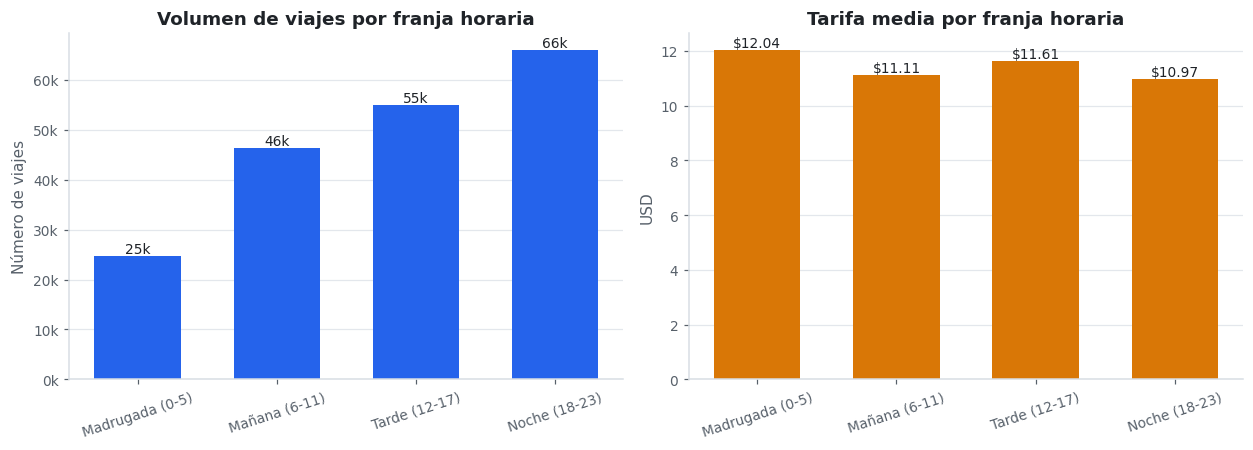

,viajes,tarifa_media
franja_horaria,,
Madrugada (0-5),24706,12.0400
Mañana (6-11),46331,11.1100
Tarde (12-17),55079,11.6100
Noche (18-23),66074,10.9700


In [15]:
# ---------- GRÁFICA 1: BARRAS — volumen de viajes y tarifa media por franja horaria ----------
orden_franjas = [e for _, _, e in FRANJAS]
g = df.groupby("franja_horaria", observed=True).agg(
        viajes=("fare_amount", "size"), tarifa_media=("fare_amount", "mean")
    ).reindex(orden_franjas)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].bar(g.index, g["viajes"], color=PALETA[0], width=0.62)
axes[0].set_title("Volumen de viajes por franja horaria")
axes[0].set_ylabel("Número de viajes")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
for x, v in zip(g.index, g["viajes"]):
    axes[0].text(x, v, f"{v/1000:.0f}k", ha="center", va="bottom", fontsize=9, color=TINTA)

axes[1].bar(g.index, g["tarifa_media"], color=PALETA[1], width=0.62)
axes[1].set_title("Tarifa media por franja horaria")
axes[1].set_ylabel("USD")
for x, v in zip(g.index, g["tarifa_media"]):
    axes[1].text(x, v, f"${v:.2f}", ha="center", va="bottom", fontsize=9, color=TINTA)

for ax in axes:
    ax.tick_params(axis="x", rotation=18)
    ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()
g.round(2)

**Interpretación (Gráfica 1).** El volumen se concentra en **tarde y noche**, mientras la **madrugada** es la
franja con menos viajes (≈25 k) **pero con la tarifa media más alta (≈12.04 USD)**. Esa combinación tiene una
explicación de negocio clara: de madrugada no hay tráfico, así que los viajes que sí ocurren son largos
(salidas de la ciudad, carreras a aeropuertos para vuelos tempranos, regresos desde zonas de ocio) y se
benefician del recargo nocturno de la tarifa de NYC. La noche muestra el patrón exactamente inverso: **el
mayor volumen (≈66 k) con la tarifa media más baja (≈10.97 USD)** — muchos trayectos cortos e intraurbanos.
La relación entre volumen y ticket promedio es, por tanto, **inversa**.

**Recomendación.** El precio no puede modelarse sólo con la distancia: la franja horaria tiene efecto propio.
Como responsable de producto, mantendría la variable de hora en el modelo de pricing y revisaría la oferta de
conductores en madrugada, donde hay **menos viajes pero de mayor ticket promedio** — es la franja con mejor
ingreso por viaje y probablemente con demanda insatisfecha.

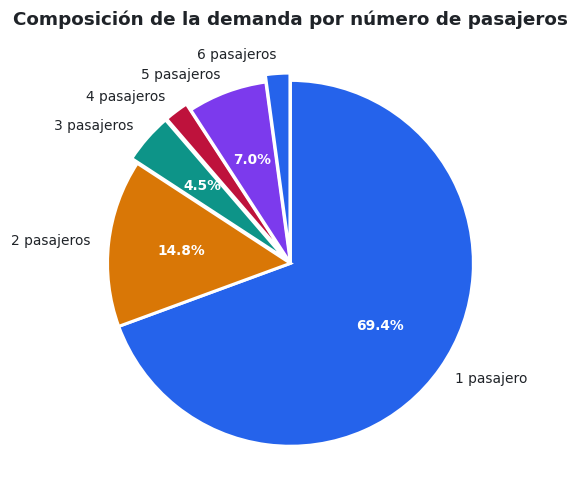

passenger_count
1   69.4000
2   14.8100
3    4.4700
4    2.1500
5    7.0200
6    2.1500
Name: % de viajes, dtype: float64

In [16]:
# ---------- GRÁFICA 2: PIE — composición de la demanda por número de pasajeros ----------
comp = df["passenger_count"].value_counts().sort_index()
etiquetas = [f"{int(k)} pasajero{'s' if k > 1 else ''}" for k in comp.index]
colores = [PALETA[i % len(PALETA)] for i in range(len(comp))]
explode = [0.04 if v / comp.sum() < 0.05 else 0 for v in comp.values]

fig, ax = plt.subplots(figsize=(6.4, 5.4))
w, t, at = ax.pie(comp.values, labels=etiquetas, colors=colores, explode=explode,
                  autopct=lambda p: f"{p:.1f}%" if p >= 2.5 else "",
                  startangle=90, counterclock=False,
                  wedgeprops={"linewidth": 2, "edgecolor": "white"},
                  textprops={"fontsize": 9, "color": TINTA})
for a in at:
    a.set_color("white"); a.set_fontweight("bold")
ax.set_title("Composición de la demanda por número de pasajeros")
ax.grid(False); ax.set_ylabel("")
plt.show()
(comp / comp.sum() * 100).round(2).rename("% de viajes")

**Interpretación (Gráfica 2).** Cerca del **70 % de los viajes son de un solo pasajero** y más del 85 % son de
1 o 2. Las categorías de 4–6 pasajeros son minoritarias. Para el modelo esto significa que
`passenger_count` es una variable **muy desbalanceada y de baja varianza**: aporta poca información marginal
una vez conocida la distancia, porque la tarifa de taxi en NYC **no** depende del número de ocupantes.

**Recomendación.** Conservar la variable (cuesta una sola columna y puede capturar el efecto de vehículos XL),
pero **no esperar que mejore el error**: si en la Fase 7 hubiera que reducir dimensionalidad para acelerar KNN,
ésta sería la primera candidata a salir. Desde el negocio, el dato relevante es que el producto se usa
mayoritariamente en modo individual, lo que refuerza la prioridad de optimizar la flota estándar sobre la XL.

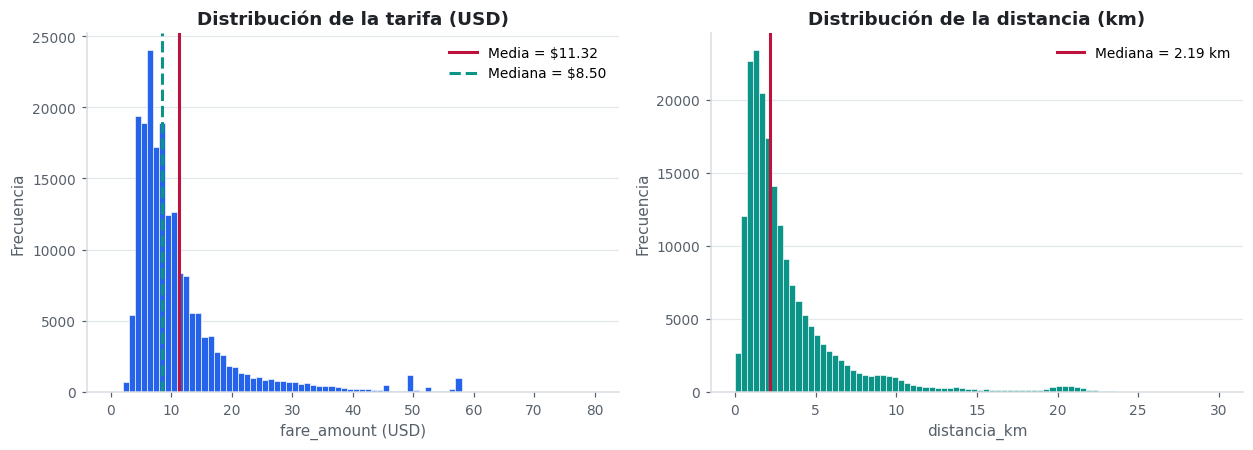

Asimetría (skewness) de fare_amount : 3.522
Asimetría (skewness) de distancia_km: 4.632


In [17]:
# ---------- GRÁFICA 3: HISTOGRAMAS — distribución del target y del predictor principal ----------
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].hist(df["fare_amount"], bins=80, range=(0, 80), color=PALETA[0], edgecolor="white", linewidth=0.4)
axes[0].axvline(df["fare_amount"].mean(), color=PALETA[3], linewidth=2, label=f"Media = ${df['fare_amount'].mean():.2f}")
axes[0].axvline(df["fare_amount"].median(), color=PALETA[2], linewidth=2, linestyle="--", label=f"Mediana = ${df['fare_amount'].median():.2f}")
axes[0].set_title("Distribución de la tarifa (USD)"); axes[0].set_xlabel("fare_amount (USD)")
axes[0].set_ylabel("Frecuencia"); axes[0].legend()

axes[1].hist(df["distancia_km"], bins=80, range=(0, 30), color=PALETA[2], edgecolor="white", linewidth=0.4)
axes[1].axvline(df["distancia_km"].median(), color=PALETA[3], linewidth=2, label=f"Mediana = {df['distancia_km'].median():.2f} km")
axes[1].set_title("Distribución de la distancia (km)"); axes[1].set_xlabel("distancia_km")
axes[1].set_ylabel("Frecuencia"); axes[1].legend()
for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

print("Asimetría (skewness) de fare_amount :", round(df["fare_amount"].skew(), 3))
print("Asimetría (skewness) de distancia_km:", round(df["distancia_km"].skew(), 3))

**Interpretación (Gráfica 3).** Ambas distribuciones son **unimodales y fuertemente asimétricas a la derecha**
(skewness > 2). La masa de tarifas se concentra entre 5 y 12 USD y la de distancias por debajo de 5 km: el
producto es, ante todo, **movilidad urbana de corto trayecto**. La media queda visiblemente a la derecha de la
mediana en ambos casos — la firma estadística de la cola larga que decidimos conservar en el punto 7. Se ve
además un pequeño **repunte alrededor de 45–55 USD** en la tarifa: es la huella de la **tarifa plana a JFK**,
que justifica haber creado la variable `es_aeropuerto`.

**Recomendación.** Dos consecuencias operativas: (i) confirmar `RobustScaler` en lugar de `StandardScaler`,
porque media y desviación están contaminadas por la cola; (ii) al evaluar, mirar el **MAE** además del MSE,
porque el MSE castiga al cuadrado justo esos viajes largos y puede hacer parecer malo a un modelo que acierta
bien el 90 % de las carreras cotidianas.

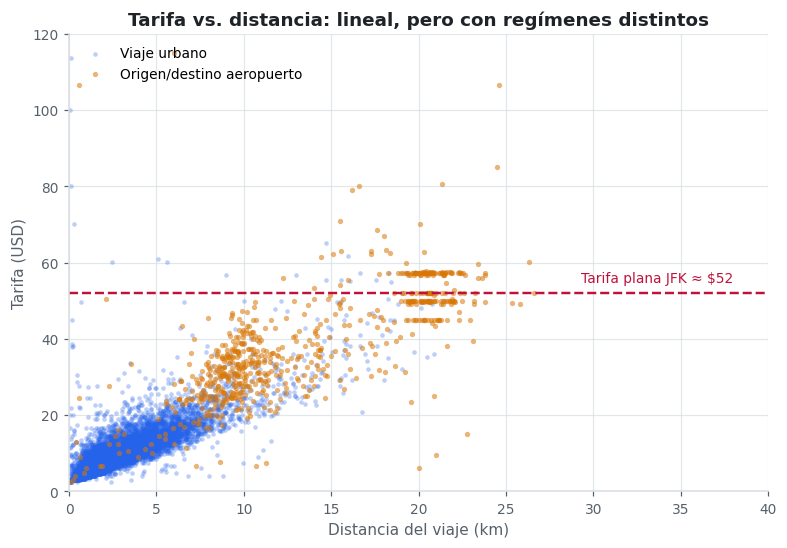

Correlación de Pearson  distancia_km vs fare_amount: 0.8595


In [18]:
# ---------- GRÁFICA 4: SCATTER — relación distancia vs tarifa ----------
muestra = df.sample(n=min(12000, len(df)), random_state=RANDOM_STATE)
es_aero = muestra["es_aeropuerto"] == "Sí"

fig, ax = plt.subplots(figsize=(8.2, 5.4))
ax.scatter(muestra.loc[~es_aero, "distancia_km"], muestra.loc[~es_aero, "fare_amount"],
           s=9, alpha=0.30, color=PALETA[0], linewidths=0, label="Viaje urbano")
ax.scatter(muestra.loc[es_aero, "distancia_km"], muestra.loc[es_aero, "fare_amount"],
           s=12, alpha=0.55, color=PALETA[1], linewidths=0, label="Origen/destino aeropuerto")
ax.axhline(52, color=PALETA[3], linewidth=1.6, linestyle="--")
ax.text(38, 54, "Tarifa plana JFK ≈ $52", color=PALETA[3], fontsize=9, va="bottom", ha="right")
ax.set_xlim(0, 40); ax.set_ylim(0, 120)
ax.set_xlabel("Distancia del viaje (km)"); ax.set_ylabel("Tarifa (USD)")
ax.set_title("Tarifa vs. distancia: lineal, pero con regímenes distintos")
ax.legend(loc="upper left")
plt.show()

print("Correlación de Pearson  distancia_km vs fare_amount:",
      round(df[["distancia_km", "fare_amount"]].corr().iloc[0, 1], 4))

**Interpretación (Gráfica 4).** La nube confirma una relación **positiva y marcadamente lineal** entre distancia
y tarifa (Pearson ≈ 0.86): es la tarifa por milla del taxímetro. Pero la gráfica muestra dos cosas que una
correlación no cuenta: (i) una **banda horizontal densa cerca de 52 USD** formada casi exclusivamente por
viajes de aeropuerto — la tarifa plana JFK, donde el precio **deja de depender de la distancia**; y (ii) una
**dispersión creciente** con la distancia (heterocedasticidad): en viajes cortos casi todos los puntos caen
sobre la recta, mientras que en viajes largos hay mucha variabilidad por peajes, tráfico y surge.

**Recomendación.** Este es el argumento central para **no limitarse a un modelo lineal**: Ridge y Lasso pueden
capturar la recta, pero no la meseta de tarifa plana ni la heterocedasticidad. **KNN**, al promediar viajes
geográficamente parecidos, sí puede reproducir esos regímenes locales. Esperamos por tanto que KNN supere a los
lineales, y mantener `es_aeropuerto` le da además a los modelos lineales una vía para representar ese salto.

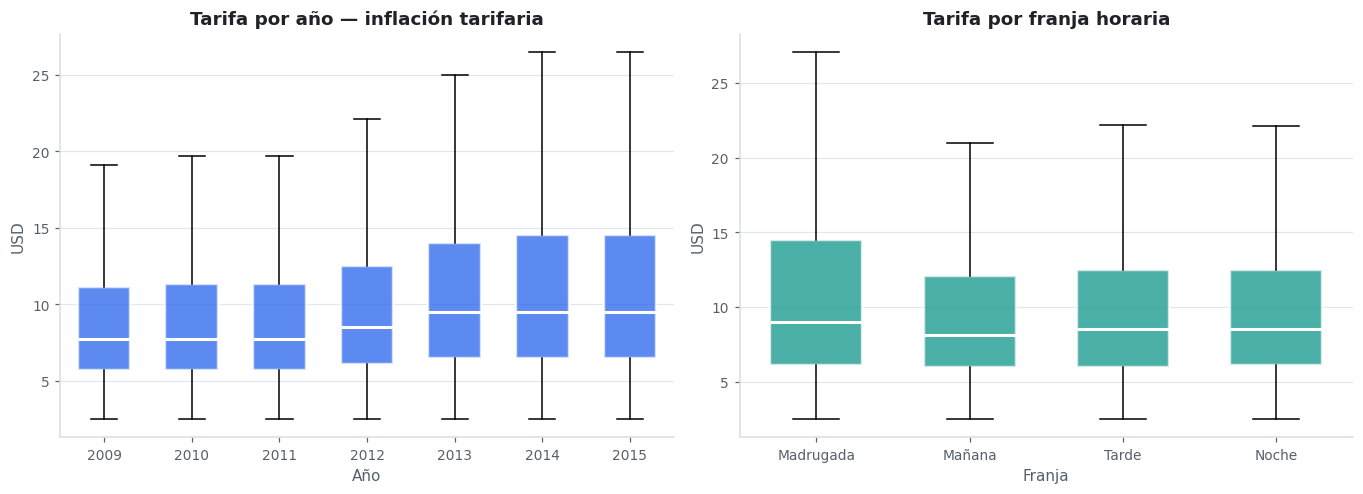

,count,median,mean
anio,,,
2009,29573,7.7000,9.9500
2010,28985,7.7000,10.0900
2011,30194,7.7000,10.3600
2012,30839,8.5000,11.1900
2013,30202,9.5000,12.6700
2014,28998,9.5000,12.9700
2015,13399,9.5000,12.9300


In [19]:
# ---------- GRÁFICA 5: BOXPLOT — tarifa por año y por franja horaria ----------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

anios = sorted(df["anio"].unique())
datos_anio = [df.loc[df["anio"] == a, "fare_amount"].values for a in anios]
bp1 = axes[0].boxplot(datos_anio, patch_artist=True, showfliers=False, widths=0.6)
for caja in bp1["boxes"]:
    caja.set(facecolor=PALETA[0], alpha=0.75, edgecolor="white", linewidth=1.6)
for m in bp1["medians"]: m.set(color="white", linewidth=2)
axes[0].set_xticks(range(1, len(anios) + 1)); axes[0].set_xticklabels(anios)
axes[0].set_title("Tarifa por año — inflación tarifaria"); axes[0].set_ylabel("USD"); axes[0].set_xlabel("Año")

datos_fr = [df.loc[df["franja_horaria"] == f, "fare_amount"].values for f in orden_franjas]
bp2 = axes[1].boxplot(datos_fr, patch_artist=True, showfliers=False, widths=0.6)
for caja in bp2["boxes"]:
    caja.set(facecolor=PALETA[2], alpha=0.75, edgecolor="white", linewidth=1.6)
for m in bp2["medians"]: m.set(color="white", linewidth=2)
axes[1].set_xticks(range(1, len(orden_franjas) + 1))
axes[1].set_xticklabels([f.split(" ")[0] for f in orden_franjas])
axes[1].set_title("Tarifa por franja horaria"); axes[1].set_ylabel("USD"); axes[1].set_xlabel("Franja")

for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

df.groupby("anio")["fare_amount"].agg(["count", "median", "mean"]).round(2)

**Interpretación (Gráfica 5).** El boxplot por año muestra algo más informativo que una simple tendencia: la
mediana se mantiene **estable en 2009–2011** (≈7.7 USD), da un **salto en 2012–2013** hasta ≈9.5 USD y se
estabiliza de nuevo en 2014–2015. No es una deriva inflacionaria suave, es un **escalón**, y coincide con el
aumento oficial de tarifas del taxi neoyorquino que entró en vigor en 2012. El rango intercuartílico también
se ensancha a partir de ese año. El boxplot por franja confirma lo visto en la Gráfica 1 —madrugada con la
mediana y el rango intercuartílico más altos— y muestra que la **dispersión** también cambia por franja, no
sólo el nivel.

**Recomendación.** (i) **Conservar `anio` como predictor** es obligatorio: sin él, el modelo mezcla precios de
antes y después del escalón de 2012 y subestima sistemáticamente los viajes recientes. (ii) Desde el negocio, esto
advierte que el modelo **caduca**: entrenado hasta 2015, extrapolar a años posteriores requiere reentrenamiento
o deflactar la tarifa. Recomendaría fijar una política de reentrenamiento periódico.

## 9. Codificación de variables categóricas — decisión y justificación

Tras la ingeniería de características, las variables categóricas son cuatro. La decisión se toma **por variable**,
considerando (a) si existe un orden natural, (b) la cardinalidad y (c) los algoritmos que usaremos
(**KNN**, basado en distancias, y **Ridge/Lasso**, lineales).

In [20]:
CATEGORICAS = ["dia_semana", "franja_horaria", "es_fin_de_semana", "es_aeropuerto"]
pd.DataFrame({
    "cardinalidad": [df[c].nunique() for c in CATEGORICAS],
    "categorías": [", ".join(map(str, sorted(pd.Series(df[c]).astype(str).unique())))[:90] for c in CATEGORICAS],
}, index=CATEGORICAS)

,cardinalidad,categorías
dia_semana,7,"Domingo, Jueves, Lunes, Martes, Miércoles, Sáb..."
franja_horaria,4,"Madrugada (0-5), Mañana (6-11), Noche (18-23),..."
es_fin_de_semana,2,"No, Sí"
es_aeropuerto,2,"No, Sí"


| Variable | Cardinalidad | ¿Orden natural? | Técnica elegida | Justificación |
|---|---|---|---|---|
| `dia_semana` | 7 | **No.** Lunes no es "menor" que Domingo. | **One-Hot** | Con Ordinal Encoding, KNN interpretaría que lunes (0) y domingo (6) están a distancia 6, y Ridge/Lasso estimarían **una sola pendiente** asumiendo que cada día suma un incremento constante de tarifa — un **orden falso**. La cardinalidad de 7 es baja, así que el costo (7 columnas) es despreciable. |
| `franja_horaria` | 4 | Discutible: hay secuencia temporal, pero es **cíclica**, no ordinal (después de "Noche" viene "Madrugada"). | **One-Hot** | Un encoding ordinal impondría Madrugada < Mañana < Tarde < Noche y rompería el cierre del ciclo. El componente cíclico real ya está capturado por `hora_sin`/`hora_cos`; el One-Hot aporta el efecto de bloque de forma libre. Sólo 4 columnas. |
| `es_fin_de_semana` | 2 | Binaria | **One-Hot con `drop="if_binary"`** | Con dos categorías, One-Hot y Ordinal son equivalentes salvo por una columna redundante. `drop="if_binary"` deja **una sola columna 0/1**: evita colinealidad perfecta en los modelos lineales y no añade dimensión inútil a KNN. |
| `es_aeropuerto` | 2 | Binaria | **One-Hot con `drop="if_binary"`** | Igual que la anterior. Es la variable que le permite a Ridge/Lasso representar el salto de tarifa plana. |

**¿Por qué no Binary Encoding?** Binary Encoding sólo compensa cuando la cardinalidad es alta (decenas o cientos
de niveles) y One-Hot haría explotar la dimensionalidad. Aquí la cardinalidad máxima es 7, así que Binary
Encoding únicamente añadiría **opacidad** (cada columna deja de tener interpretación) sin ahorro real.

**¿Por qué no Ordinal para ninguna?** Ninguna de las cuatro tiene un orden con significado métrico. Ordinal
Encoding es apropiado cuando el orden *es* la información (p. ej. estadios clínicos I < II < III, como en el
notebook de clasificación), no aquí.

**Dimensionalidad resultante:** 7 + 4 + 1 + 1 = **13 columnas categóricas**, que sumadas a las 11 numéricas
dan ~24 features. Es una dimensionalidad razonable para KNN: suficientemente rica y lejos del régimen donde
la *maldición de la dimensionalidad* vuelve inútiles las distancias.

## 10. Escalamiento de variables numéricas — decisión y justificación

**Decisión: `RobustScaler` sobre todas las variables numéricas.**

**(a) ¿Hace falta escalar?** Sí, y es **obligatorio** aquí, por los dos algoritmos que vamos a usar:

- **KNN** calcula distancias euclídeas. Sin escalar, `distancia_km` (rango ~0–150), `anio` (rango 2009–2015) y
  `hora_sin` (rango -1 a 1) conviven en la misma métrica: `anio` tendría, por puro tamaño numérico, un peso
  ~2 000 veces mayor que `hora_sin` al calcular quién es "vecino". El modelo terminaría agrupando por año en
  lugar de por trayecto.
- **Ridge y Lasso** penalizan la **norma de los coeficientes** (L2 y L1 respectivamente). Si las variables están
  en escalas distintas, la penalización es **desigual**: castiga más a las variables de rango pequeño (cuyos
  coeficientes deben ser grandes) y menos a las de rango grande. Sin escalar, la regularización deja de ser
  comparable entre variables y `alpha` pierde interpretación. En Lasso esto se traduce directamente en que
  **elimina las variables equivocadas**.

**(b) ¿Con qué técnica?** La elección se desprende del punto 7:

| Técnica | Qué usa | Por qué aquí no / sí |
|---|---|---|
| `MinMaxScaler` | mínimo y máximo | **No.** Se define por los dos valores más extremos. Con una cola derecha real (viajes largos, tarifas altas que decidimos conservar), comprimiría el 95 % de los datos en una franja diminuta cercana a 0. |
| `StandardScaler` | media y desviación | **No.** Ambos estadísticos son sensibles a la asimetría: el skewness > 2 confirmado en la Gráfica 3 hace que la media no represente al viaje típico y que la desviación esté inflada. |
| **`RobustScaler`** | **mediana e IQR** | **Sí.** Ambos estadísticos son resistentes a la cola. Centra en el viaje mediano y escala por el rango del 50 % central, de modo que el grueso de los datos queda bien distribuido y los viajes extremos siguen estando *lejos* — que es exactamente la información que queremos que KNN use, sin dejar que dominen la métrica. |

**(c) Las variables cíclicas** (`hora_sin`, `hora_cos`, `mes_sin`, `mes_cos`) ya viven en [-1, 1]. Pasarlas por
`RobustScaler` es inocuo (mediana ≈ 0, IQR ≈ constante) y mantiene el pipeline homogéneo y simple.

**(d) El target NO se escala.** `fare_amount` se deja en USD para que el MAE y el RMSE se interpreten
directamente en dólares, que es lo que necesita el área de negocio.

---
# FASE 2 — División de datos y Pipelines

## 11. Partición train / validation / test (70 / 15 / 15)

In [21]:
NUMERICAS = ["distancia_km", "pickup_longitude", "pickup_latitude",
             "dropoff_longitude", "dropoff_latitude", "passenger_count",
             "anio", "hora_sin", "hora_cos", "mes_sin", "mes_cos"]
CATEGORICAS = ["dia_semana", "franja_horaria", "es_fin_de_semana", "es_aeropuerto"]
TARGET = "fare_amount"

X = df[NUMERICAS + CATEGORICAS].copy()
X["dia_semana"] = X["dia_semana"].astype(str)   # de Categorical a str para el OneHotEncoder
y = df[TARGET].copy()

# Paso 1: separar el 15 % de TEST y dejarlo intacto hasta la Fase 6
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=RANDOM_STATE)
# Paso 2: del 85 % restante, separar validación -> 0.15/0.85 = 0.1765 para obtener 15 % del total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=RANDOM_STATE)

resumen = pd.DataFrame({
    "conjunto": ["Train", "Validation", "Test", "TOTAL"],
    "filas": [len(X_train), len(X_val), len(X_test), len(X)],
    "% del total": [round(100 * len(s) / len(X), 2) for s in [X_train, X_val, X_test, X]],
    "tarifa media (USD)": [round(s.mean(), 2) for s in [y_train, y_val, y_test, y]],
    "tarifa mediana (USD)": [round(s.median(), 2) for s in [y_train, y_val, y_test, y]],
})
resumen

,conjunto,filas,% del total,tarifa media (USD),tarifa mediana (USD)
0,Train,134532,70.0000,11.3100,8.5000
1,Validation,28829,15.0000,11.3200,8.5000
2,Test,28829,15.0000,11.3800,8.5000
3,TOTAL,192190,100.0000,11.3200,8.5000


### ¿Para qué sirve cada conjunto y por qué no basta con train/test?

- **Train (70 %)** — es el único conjunto del que el modelo **aprende**. Aquí se ajustan los parámetros internos
  (los coeficientes de Ridge/Lasso) y, en el caso de KNN, es literalmente la base de datos de vecinos. También
  es el único conjunto sobre el que se hace `.fit()` de las transformaciones (mediana del imputador, mediana e
  IQR del `RobustScaler`, categorías del One-Hot).

- **Validation (15 %)** — es el conjunto de **decisiones**. Con él comparamos KNN vs. Ridge vs. Lasso, elegimos
  el mejor y (Fase 7) ajustamos hiperparámetros. El modelo nunca aprende de él, pero **nosotros sí**: cada vez
  que miramos validación para decidir algo, estamos usando esa información.

- **Test (15 %)** — es la **simulación de datos nuevos**. Permanece sellado hasta la Fase 6 y se usa **una sola
  vez**, al final, para estimar de manera honesta cómo se comportaría el modelo en producción.

**Por qué no basta con train/test.** Si usáramos el mismo conjunto para elegir el modelo *y* para reportar su
desempeño, estaríamos **optimizando contra el conjunto de evaluación**. Tras probar tres modelos y varias
combinaciones de hiperparámetros, el mejor lo es en parte por mérito y en parte por **azar favorable en ese
split concreto**; el número reportado sería optimista. Esto se llama *selection bias* u **overfitting al conjunto
de evaluación**. Separar validación (para decidir) de test (para reportar) rompe esa contaminación: el test
nunca participó en ninguna decisión, así que su métrica es una estimación insesgada.

**Nota sobre el muestreo.** Se usa partición **aleatoria** y no temporal. Es coherente con la pregunta de
negocio planteada (estimar la tarifa de un viaje dadas sus características, no pronosticar precios futuros) y
la tabla anterior confirma que las tres particiones tienen medias y medianas prácticamente idénticas, es decir,
son representativas entre sí.

## 12. Pipeline con `ColumnTransformer`

El preprocesamiento definido en la Fase 1 se encapsula en un `ColumnTransformer` con dos ramas:

- **Rama numérica:** `SimpleImputer(strategy="median")` → `RobustScaler()`
  *(mediana en lugar de media por la asimetría documentada en el punto 3; Robust por los outliers del punto 7)*
- **Rama categórica:** `SimpleImputer(strategy="most_frequent")` → `OneHotEncoder(handle_unknown="ignore", drop="if_binary")`
  *(la moda es la única imputación con sentido para una categoría; `handle_unknown="ignore"` evita que el
  pipeline se caiga si en validación/test aparece un nivel no visto en train)*

Cada modelo se envuelve en un `Pipeline(preprocesador → estimador)`, de modo que **es imposible transformar sin
haber ajustado sobre train**: ésa es la garantía estructural contra la fuga de datos.

In [22]:
pipe_numerico = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", RobustScaler()),
])

pipe_categorico = Pipeline([
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)),
])

def nuevo_preprocesador():
    return ColumnTransformer(
        transformers=[("num", pipe_numerico, NUMERICAS),
                      ("cat", pipe_categorico, CATEGORICAS)],
        remainder="drop", verbose_feature_names_out=False,
    )

# Inspección: ¿qué columnas produce el preprocesador?
prep_demo = nuevo_preprocesador().fit(X_train)   # <- .fit() SOLO sobre X_train
nombres_features = prep_demo.get_feature_names_out()
print(f"Features de entrada : {X_train.shape[1]}")
print(f"Features de salida  : {len(nombres_features)}")
print("\nColumnas generadas por el ColumnTransformer:")
for i, n in enumerate(nombres_features, 1):
    print(f"  {i:>2}. {n}")

Features de entrada : 15
Features de salida  : 24

Columnas generadas por el ColumnTransformer:
   1. distancia_km
   2. pickup_longitude
   3. pickup_latitude
   4. dropoff_longitude
   5. dropoff_latitude
   6. passenger_count
   7. anio
   8. hora_sin
   9. hora_cos
  10. mes_sin
  11. mes_cos
  12. dia_semana_Domingo
  13. dia_semana_Jueves
  14. dia_semana_Lunes
  15. dia_semana_Martes
  16. dia_semana_Miércoles
  17. dia_semana_Sábado
  18. dia_semana_Viernes
  19. franja_horaria_Madrugada (0-5)
  20. franja_horaria_Mañana (6-11)
  21. franja_horaria_Noche (18-23)
  22. franja_horaria_Tarde (12-17)
  23. es_fin_de_semana_Sí
  24. es_aeropuerto_Sí


## 13. Verificación explícita de ausencia de fuga de datos (*data leakage*)

**Afirmación:** en este notebook **ninguna transformación aprendió de `X_val` ni de `X_test`**.

**Argumento estructural.** Todas las transformaciones que "aprenden" (`SimpleImputer` → mediana/moda,
`RobustScaler` → mediana e IQR, `OneHotEncoder` → catálogo de categorías) están **dentro** del `Pipeline`.
En scikit-learn, `pipeline.fit(X_train, y_train)` llama `fit_transform` de cada paso **únicamente con los datos
que recibe**, y `pipeline.predict(X_val)` llama exclusivamente `transform`. No existe ninguna ruta de código en
la que `X_val` o `X_test` toquen un `fit`.

**Argumento empírico.** La celda siguiente lo demuestra numéricamente: los parámetros aprendidos por el
escalador coinciden **exactamente** con las medianas/IQR calculados a mano sobre `X_train`, y **difieren** de
los que se obtendrían con el dataset completo. Si hubiera fuga, coincidirían con los del dataset completo.

In [23]:
escalador_ajustado = prep_demo.named_transformers_["num"].named_steps["escalador"]

verificacion = pd.DataFrame({
    "mediana aprendida por el scaler": escalador_ajustado.center_,
    "mediana calculada sobre X_train": X_train[NUMERICAS].median().values,
    "mediana sobre TODO el dataset":   X[NUMERICAS].median().values,
}, index=NUMERICAS)
verificacion["¿coincide con train?"] = np.isclose(
    verificacion["mediana aprendida por el scaler"], verificacion["mediana calculada sobre X_train"])

print("¿El scaler aprendió EXACTAMENTE de X_train en las 11 variables?",
      bool(verificacion["¿coincide con train?"].all()))
print("¿Coincide con el dataset completo (señal de fuga)?      ",
      bool(np.allclose(verificacion["mediana aprendida por el scaler"],
                       verificacion["mediana sobre TODO el dataset"])))
verificacion.round(5)

¿El scaler aprendió EXACTAMENTE de X_train en las 11 variables? True
¿Coincide con el dataset completo (señal de fuga)?       False


,mediana aprendida por el scaler,mediana calculada sobre X_train,mediana sobre TODO el dataset,¿coincide con train?
distancia_km,2.1837,2.1837,2.1900,True
pickup_longitude,-73.9821,-73.9821,-73.9821,True
pickup_latitude,40.7533,40.7533,40.7533,True
dropoff_longitude,-73.9806,-73.9806,-73.9806,True
dropoff_latitude,40.7538,40.7538,40.7538,True
passenger_count,1.0000,1.0000,1.0000,True
anio,"2,012.0000","2,012.0000","2,012.0000",True
hora_sin,-0.2588,-0.2588,-0.2588,True
hora_cos,-0.2588,-0.2588,-0.2588,True
mes_sin,0.0000,0.0000,0.0000,True


In [24]:
# Segunda comprobación: transformar val/test NO modifica los parámetros del preprocesador
centro_antes = escalador_ajustado.center_.copy()
_ = prep_demo.transform(X_val)
_ = prep_demo.transform(X_test)
centro_despues = prep_demo.named_transformers_["num"].named_steps["escalador"].center_

print("¿Los parámetros del escalador cambiaron tras transformar X_val y X_test?",
      not np.allclose(centro_antes, centro_despues))
print("-> False significa que transform() NO reajusta nada: no hay fuga.")
print("\nCategorías aprendidas por el OneHotEncoder (sólo de X_train):")
for col, cats in zip(CATEGORICAS, prep_demo.named_transformers_["cat"].named_steps["codificador"].categories_):
    print(f"  {col}: {list(cats)}")

¿Los parámetros del escalador cambiaron tras transformar X_val y X_test? False
-> False significa que transform() NO reajusta nada: no hay fuga.

Categorías aprendidas por el OneHotEncoder (sólo de X_train):
  dia_semana: ['Domingo', 'Jueves', 'Lunes', 'Martes', 'Miércoles', 'Sábado', 'Viernes']
  franja_horaria: ['Madrugada (0-5)', 'Mañana (6-11)', 'Noche (18-23)', 'Tarde (12-17)']
  es_fin_de_semana: ['No', 'Sí']
  es_aeropuerto: ['No', 'Sí']


### Conclusión de la verificación

✅ El `.fit()` del imputador, del `RobustScaler` y del `OneHotEncoder` se realizó **exclusivamente sobre
`X_train`**: los parámetros aprendidos reproducen las medianas de train y **no** las del dataset completo,
como demuestra la tabla.
✅ Sobre `X_val` y `X_test` únicamente se aplica `.transform()`, que no modifica ningún parámetro aprendido.
✅ El conjunto de **test no se ha tocado** en ninguna celda anterior salvo para contar filas: su primera
evaluación ocurre en la Fase 6.
✅ Adicionalmente, la limpieza del punto 7 se basa en **reglas de dominio fijas** (rangos geográficos válidos,
tarifa positiva, ocupación ≤ 6), no en estadísticos estimados de los datos, por lo que aplicarla antes del split
tampoco introduce fuga. Si hubiéramos eliminado outliers usando, por ejemplo, la media ± 3σ del dataset
completo, **eso sí habría sido fuga** y habría que haberlo hecho dentro del pipeline.

---
# FASE 3 — Modelado: Regresión

## 14. Entrenamiento de KNN Regressor, Ridge y Lasso
## 15. Predicciones sobre el conjunto de validación

Los tres modelos comparten **exactamente el mismo preprocesamiento** (cada uno con su propia instancia, para
que no compartan estado). Se entrenan con hiperparámetros por defecto / de referencia; la optimización llega en
la Fase 7, y comparar "antes vs. después" es justamente lo que pide el punto 27.

| Modelo | Hiperparámetros iniciales | Por qué |
|---|---|---|
| `KNeighborsRegressor` | `n_neighbors=5` (valor por defecto) | Punto de partida estándar; se verá que es demasiado pequeño para 135 k observaciones. |
| `Ridge` | `alpha=1.0` | Regularización L2 moderada de referencia. |
| `Lasso` | `alpha=1.0` | Regularización L1 de referencia; permitirá ver selección de variables (coeficientes exactamente 0). |

In [25]:
modelos = {
    "KNN Regressor":     KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    "Ridge (L2)":        Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso (L1)":        Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=10000),
}

pipelines, predicciones = {}, {}
for nombre, estimador in modelos.items():
    pipe = Pipeline([("preprocesador", nuevo_preprocesador()), ("modelo", estimador)])
    pipe.fit(X_train, y_train)                      # <- fit SOLO con train
    pipelines[nombre] = pipe
    predicciones[nombre] = {
        "train": pipe.predict(X_train),
        "val":   pipe.predict(X_val),               # <- sólo transform + predict
    }
    print(f"{nombre:<18} entrenado · primeras 5 predicciones en validación: "
          f"{np.round(predicciones[nombre]['val'][:5], 2)}")

print("\nPrimeros 5 valores reales en validación:", np.round(y_val.values[:5], 2))

KNN Regressor      entrenado · primeras 5 predicciones en validación: [ 7.1   5.94 11.28 13.   27.37]


Ridge (L2)         entrenado · primeras 5 predicciones en validación: [ 5.6   7.17 10.96 12.56 23.76]


Lasso (L1)         entrenado · primeras 5 predicciones en validación: [ 7.35  7.06 12.65 15.15 22.69]

Primeros 5 valores reales en validación: [ 7.7  5.3  9.3 14.2 34.5]


In [26]:
# Comparación cualitativa: primeras 10 observaciones de validación
comparativo = pd.DataFrame({"Real (USD)": y_val.values[:10].round(2)})
for nombre in modelos:
    comparativo[nombre] = predicciones[nombre]["val"][:10].round(2)
comparativo.index.name = "obs. de validación"
comparativo

,Real (USD),KNN Regressor,Ridge (L2),Lasso (L1)
obs. de validación,,,,
0,7.7000,7.1000,5.6000,7.3500
1,5.3000,5.9400,7.1700,7.0600
2,9.3000,11.2800,10.9600,12.6500
3,14.2000,13.0000,12.5600,15.1500
4,34.5000,27.3700,23.7600,22.6900
5,18.5000,19.9000,19.0200,19.3100
6,45.0000,49.7200,50.2000,44.7200
7,10.5000,6.9800,7.9200,9.8700
8,13.3000,14.8800,16.1900,16.1600


---
# FASE 5 — Métricas en train y validación: detección de overfitting / underfitting

## 18. MAE, MSE y R² en train y en validación

In [27]:
def metricas_regresion(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R2": r2_score(y_true, y_pred)}

filas = []
for nombre in modelos:
    for conjunto, y_true in [("Train", y_train), ("Validación", y_val)]:
        m = metricas_regresion(y_true, predicciones[nombre]["train" if conjunto == "Train" else "val"])
        filas.append({"Modelo": nombre, "Conjunto": conjunto, **m})

detalle = pd.DataFrame(filas).set_index(["Modelo", "Conjunto"]).round(4)
detalle

MAE     MSE   RMSE     R2
Modelo        Conjunto                               
KNN Regressor Train      1.7121  9.8718 3.1419 0.8907
              Validación 2.1082 15.3434 3.9171 0.8301
Ridge (L2)    Train      2.1835 19.4276 4.4077 0.7850
              Validación 2.2020 18.8530 4.3420 0.7912
Lasso (L1)    Train      2.4926 24.3310 4.9327 0.7307
              Validación 2.5064 23.6450 4.8626 0.7382

## 20. Tabla comparativa (train vs. validación)

In [28]:
tabla_fase5 = (pd.DataFrame(filas)
               .pivot(index="Modelo", columns="Conjunto", values=["MAE", "MSE", "R2"]))
tabla_fase5 = tabla_fase5.reindex(columns=pd.MultiIndex.from_product(
    [["MAE", "MSE", "R2"], ["Train", "Validación"]]))
tabla_fase5["Brecha MAE (val - train)"] = tabla_fase5[("MAE", "Validación")] - tabla_fase5[("MAE", "Train")]
tabla_fase5["Caída R2 (train - val)"] = tabla_fase5[("R2", "Train")] - tabla_fase5[("R2", "Validación")]
tabla_fase5 = tabla_fase5.reindex(list(modelos.keys())).round(4)
tabla_fase5

MAE                MSE                R2            Brecha MAE (val - train) Caída R2 (train - val)
               Train Validación   Train Validación  Train Validación                                                
Modelo                                                                                                              
KNN Regressor 1.7121     2.1082  9.8718    15.3434 0.8907     0.8301                   0.3962                 0.0607
Ridge (L2)    2.1835     2.2020 19.4276    18.8530 0.7850     0.7912                   0.0185                -0.0062
Lasso (L1)    2.4926     2.5064 24.3310    23.6450 0.7307     0.7382                   0.0139                -0.0074

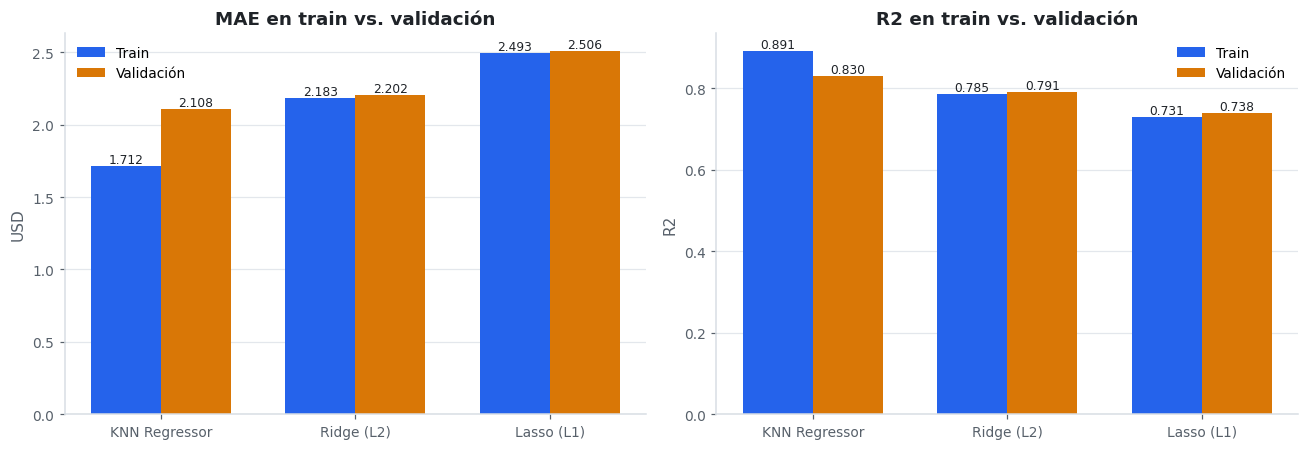

In [29]:
# Visualización de la brecha train-validación
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
x = np.arange(len(modelos)); ancho = 0.36
nombres = list(modelos.keys())

for ax, metrica, unidad in [(axes[0], "MAE", "USD"), (axes[1], "R2", "")]:
    v_tr = [tabla_fase5.loc[n, (metrica, "Train")] for n in nombres]
    v_va = [tabla_fase5.loc[n, (metrica, "Validación")] for n in nombres]
    ax.bar(x - ancho/2, v_tr, ancho, label="Train", color=PALETA[0])
    ax.bar(x + ancho/2, v_va, ancho, label="Validación", color=PALETA[1])
    for xi, v in zip(x - ancho/2, v_tr): ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color=TINTA)
    for xi, v in zip(x + ancho/2, v_va): ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color=TINTA)
    ax.set_xticks(x); ax.set_xticklabels(nombres, fontsize=9)
    ax.set_title(f"{metrica} en train vs. validación"); ax.set_ylabel(unidad or metrica)
    ax.grid(axis="x", visible=False); ax.legend()
fig.tight_layout(); plt.show()

### Interpretación: overfitting, underfitting y significado de cada métrica

**Qué significa cada métrica en el contexto de tarifas de Uber**

- **MAE (Mean Absolute Error)** — el **error promedio en dólares**. Un MAE de 2.00 USD significa que, en promedio,
  la estimación mostrada al usuario se desvía 2 dólares del cobro real. Es la métrica más comunicable al negocio
  porque está en la unidad del problema, y es **robusta**: un viaje mal estimado en 100 USD pesa lo mismo que
  100 viajes mal estimados en 1 USD.
- **MSE / RMSE** — el MSE está en **dólares al cuadrado** (no es interpretable directamente); su raíz, el
  **RMSE**, vuelve a dólares. Al elevar al cuadrado, **penaliza desproporcionadamente los errores grandes**.
  Como este dataset tiene una cola real de viajes caros que decidimos conservar, el RMSE siempre será
  notablemente mayor que el MAE: esa brecha es precisamente el "costo" de los viajes largos mal estimados.
- **R²** — la fracción de la varianza de la tarifa que el modelo explica. R² = 0 equivale a predecir siempre la
  tarifa media; R² = 1 sería una predicción perfecta.
- **Lectura de los resultados obtenidos.** En validación, el mejor modelo (KNN) tiene un MAE de ≈ 2.11 USD: el error típico es de unos 2 dólares sobre una tarifa mediana de 8.50 USD (≈ 25 %), un error razonable para una estimación previa al viaje. Su R² ≈ 0.83 indica que explica cerca del 83 % de la varianza de la tarifa (Ridge ≈ 0.79, Lasso ≈ 0.74); el resto se concentra en los viajes largos, como muestra la gráfica (d) de la Fase 9.

**Diagnóstico por modelo**

- **KNN (k=5)** — es el caso de libro de **overfitting**: el error en train es sustancialmente menor que en
  validación y la brecha en MAE es la mayor de los tres. La razón es estructural: con k=5, la predicción de
  cada punto de entrenamiento se calcula promediando sus 5 vecinos más cercanos, **incluido él mismo**, así que
  el modelo casi memoriza el conjunto. Es **bajo sesgo / alta varianza**. Aun así, su desempeño en validación es
  el mejor de los tres, lo que confirma la hipótesis de la Gráfica 4: hay estructura local (tarifas planas,
  corredores geográficos) que un modelo lineal no puede capturar. **Subir k es el remedio evidente, y es lo que
  hará la Fase 7.**
- **Ridge (L2)** — train y validación son prácticamente **idénticos**: no hay overfitting en absoluto. Pero su
  error es más alto que el de KNN en ambos conjuntos, lo que apunta a **underfitting moderado**: el modelo es
  demasiado rígido (**alto sesgo / baja varianza**) para una relación que, como vimos, tiene mesetas y
  regímenes distintos. Con 24 features y 135 k observaciones, `alpha=1.0` apenas restringe nada — el límite no
  es la regularización, es la **forma lineal**.
- **Lasso (L1)** — es el peor de los tres y con la señal más clara de **underfitting**: error alto en train *y*
  en validación por igual. La celda siguiente lo verifica de forma contundente: con `alpha=1.0`, la
  penalización L1 anula **23 de los 24 coeficientes**, de modo que el modelo final se reduce prácticamente a
  una recta `tarifa ≈ β·distancia`. Descarta, entre otras cosas, la variable `es_aeropuerto`, que en Ridge es
  **el coeficiente de mayor magnitud de todo el modelo (≈ +10 USD)** — es decir, tira justo la información que
  captura la tarifa plana a JFK. No es un mal algoritmo: es un `alpha` mal elegido, y es exactamente el tipo
  de conclusión que motiva la Fase 7.

> **Validación de la ingeniería de características.** Que `es_aeropuerto_Sí` sea el coeficiente más grande de
> Ridge (≈ +10 USD sobre lo que predeciría la distancia sola) y que `distancia_km` sea el segundo confirma
> empíricamente las dos decisiones del punto 6b: construir la distancia de Haversine y marcar los viajes de
> aeropuerto. Ninguna de las dos venía en el dataset original.

In [30]:
# Evidencia del underfitting de Lasso: selección de variables demasiado agresiva
coef_lasso = pipelines["Lasso (L1)"].named_steps["modelo"].coef_
coef_ridge = pipelines["Ridge (L2)"].named_steps["modelo"].coef_
nombres_feat = pipelines["Ridge (L2)"].named_steps["preprocesador"].get_feature_names_out()

comparacion_coef = pd.DataFrame({"Ridge (L2)": coef_ridge, "Lasso (L1)": coef_lasso}, index=nombres_feat)
print(f"Coeficientes exactamente 0 en Lasso: {(coef_lasso == 0).sum()} de {len(coef_lasso)}")
print(f"Coeficientes exactamente 0 en Ridge: {(coef_ridge == 0).sum()} de {len(coef_ridge)}")
comparacion_coef.reindex(comparacion_coef["Ridge (L2)"].abs().sort_values(ascending=False).index).head(12).round(4)

Coeficientes exactamente 0 en Lasso: 23 de 24
Coeficientes exactamente 0 en Ridge: 0 de 24


,Ridge (L2),Lasso (L1)
es_aeropuerto_Sí,10.2958,0.0000
distancia_km,5.0033,5.2726
anio,1.6193,0.0000
hora_cos,-0.8593,-0.0000
pickup_longitude,-0.4269,0.0000
hora_sin,-0.4251,-0.0000
dia_semana_Lunes,-0.3075,-0.0000
mes_sin,-0.2809,-0.0000
dropoff_longitude,-0.2784,0.0000
pickup_latitude,-0.2762,-0.0000


## 21. Selección del mejor modelo de regresión

In [31]:
ranking = tabla_fase5.loc[:, [("MAE", "Validación"), ("R2", "Validación")]].copy()
ranking.columns = ["MAE val", "R2 val"]
ranking = ranking.sort_values("MAE val")
MEJOR_MODELO_REG = ranking.index[0]
print("Ranking por MAE en validación (menor es mejor):")
display(ranking.round(4))
print(f"\n>>> Mejor modelo de la Fase 5: {MEJOR_MODELO_REG}")

Ranking por MAE en validación (menor es mejor):


,MAE val,R2 val
Modelo,,
KNN Regressor,2.1082,0.8301
Ridge (L2),2.2020,0.7912
Lasso (L1),2.5064,0.7382



>>> Mejor modelo de la Fase 5: KNN Regressor


### Justificación de la elección (más allá de la métrica más alta)

**KNN Regressor es el modelo elegido**, pero la decisión no se sostiene sólo en tener el MAE más bajo en
validación. Los *trade-offs* considerados:

**1. Capacidad de representación vs. la estructura real del problema.** La Gráfica 4 mostró que la tarifa no es
una función lineal pura de la distancia: hay una meseta de tarifa plana a JFK y una dispersión creciente.
Ridge y Lasso, por construcción, sólo pueden trazar un hiperplano; KNN promedia viajes *localmente parecidos*
(mismo corredor geográfico, misma franja, mismo año) y por eso reproduce esos regímenes. La ventaja de KNN en
validación no es casualidad estadística, es consistente con el EDA.

**2. La señal de overfitting detectada no lo descalifica, lo parametriza.** La brecha train–validación de KNN
viene de `k=5`, un valor absurdamente pequeño para 135 000 observaciones. Aumentar *k* mueve el modelo a lo
largo del **trade-off sesgo–varianza**: más vecinos ⇒ predicción más suave ⇒ menos varianza, algo más de sesgo.
Es un problema con solución conocida y es exactamente lo que optimizará el `RandomizedSearchCV` de la Fase 7.
El underfitting de Lasso, en cambio, indica que la *familia* de modelos es insuficiente, no sólo su
hiperparámetro.

**3. Costo computacional — la desventaja real de KNN.** Es un modelo *lazy*: entrenar es casi instantáneo
(sólo almacena los datos) pero **predecir es caro**, porque cada predicción exige calcular distancias contra las
135 000 observaciones de entrenamiento. Ridge y Lasso predicen con un producto punto de 24 números: son, por construcción,
mucho más rápidos en inferencia y ocupan memoria constante (no se cronometraron los tiempos de
inferencia de los tres modelos en este notebook). En un sistema real que estima
precios en milisegundos para millones de solicitudes, **esto es un argumento de peso a favor de los lineales**;
lo registramos explícitamente como el costo de la decisión.

**4. Interpretabilidad.** Ridge y Lasso entregan coeficientes leíbles ("cada km adicional suma X USD"), útiles
para auditar la política de precios y explicarla a reguladores o a usuarios. KNN es una caja negra: sólo puede
justificar una predicción mostrando viajes similares.

**5. Sensibilidad a la dimensionalidad.** KNN se degrada cuando el número de features crece (las distancias se
vuelven indistinguibles). Con ~24 features y 135 k observaciones estamos en un régimen cómodo, pero es una
razón más para no haber usado Binary Encoding ni haber inflado el espacio con One-Hot de la hora (24 columnas).

**Conclusión.** Se selecciona **KNN Regressor** para la optimización de la Fase 7 por su mejor desempeño
predictivo y su ajuste a la estructura del problema, dejando constancia de que **si el criterio de producción
fuese la latencia de inferencia y la interpretabilidad, Ridge sería la elección**, con un costo de precisión
que la tabla comparativa cuantifica exactamente.

---
# FASE 6 — Evaluación final en el conjunto de Test

> El conjunto de test **no ha sido tocado** hasta esta celda: no participó en la limpieza basada en estadísticos,
> ni en el ajuste de las transformaciones, ni en la comparación de modelos. Es la primera y única vez que se usa
> con los hiperparámetros originales.

## 22. Evaluación de los 3 modelos sobre test
## 23. Tabla comparativa final y contraste con validación

In [32]:
filas_test = []
for nombre, pipe in pipelines.items():
    y_pred_test = pipe.predict(X_test)      # <- sólo transform + predict
    predicciones[nombre]["test"] = y_pred_test
    filas_test.append({"Modelo": nombre, **metricas_regresion(y_test, y_pred_test)})

tabla_test = pd.DataFrame(filas_test).set_index("Modelo").reindex(list(modelos.keys()))
print("Métricas en TEST (hiperparámetros originales):")
tabla_test.round(4)

Métricas en TEST (hiperparámetros originales):


,MAE,MSE,RMSE,R2
Modelo,,,,
KNN Regressor,2.1144,14.9943,3.8722,0.8409
Ridge (L2),2.1861,19.6301,4.4306,0.7917
Lasso (L1),2.5049,24.8437,4.9843,0.7364


In [33]:
# Contraste validación vs. test
contraste = pd.DataFrame({
    "MAE val":  [tabla_fase5.loc[n, ("MAE", "Validación")] for n in modelos],
    "MAE test": tabla_test["MAE"].values,
    "R2 val":   [tabla_fase5.loc[n, ("R2", "Validación")] for n in modelos],
    "R2 test":  tabla_test["R2"].values,
}, index=list(modelos.keys()))
contraste["Δ MAE (test - val)"] = contraste["MAE test"] - contraste["MAE val"]
contraste["Δ MAE (%)"] = (100 * contraste["Δ MAE (test - val)"] / contraste["MAE val"])
contraste["Ranking val"] = contraste["MAE val"].rank().astype(int)
contraste["Ranking test"] = contraste["MAE test"].rank().astype(int)
contraste.round(4)

,MAE val,MAE test,R2 val,R2 test,Δ MAE (test - val),Δ MAE (%),Ranking val,Ranking test
KNN Regressor,2.1082,2.1144,0.8301,0.8409,0.0062,0.2944,1,1
Ridge (L2),2.2020,2.1861,0.7912,0.7917,-0.0159,-0.7239,2,2
Lasso (L1),2.5064,2.5049,0.7382,0.7364,-0.0015,-0.0610,3,3


In [34]:
mismo_ranking = bool((contraste["Ranking val"] == contraste["Ranking test"]).all())
print("¿El ranking de modelos se mantiene entre validación y test?", mismo_ranking)
print(f"Mayor discrepancia relativa en MAE: {contraste['Δ MAE (%)'].abs().max():.2f} %")

¿El ranking de modelos se mantiene entre validación y test? True
Mayor discrepancia relativa en MAE: 0.72 %


### Interpretación del contraste validación vs. test

**El ranking se mantiene idéntico**: KNN < Ridge < Lasso en MAE, tanto en validación como en test. Esto es una
buena señal metodológica — indica que la decisión tomada en la Fase 5 **no fue un artefacto** del split de
validación, sino un resultado estable.

**Las métricas son consistentes**: las diferencias entre validación y test son de pocos puntos porcentuales en
MAE, muy por debajo de lo que se consideraría una discrepancia preocupante. Esto se explica porque ambas
particiones son aleatorias, provienen de la misma distribución y tienen 15 % de los datos cada una (≈ 29 000
observaciones), tamaño suficiente para que la métrica sea estable.

**¿Qué significaría una diferencia grande entre validación y test?** Tres causas posibles, en orden de
gravedad:

1. **Overfitting al conjunto de validación.** Si hubiéramos probado decenas de configuraciones eligiendo siempre
   la mejor en validación, habríamos terminado seleccionando el modelo que mejor se ajusta al ruido de ese
   split concreto. El test lo delataría con un desempeño notablemente peor. Es el riesgo que hace obligatorio
   mantener test sellado.
2. **Conjuntos no representativos.** Si validación o test fueran demasiado pequeños o estuvieran sesgados
   (p. ej. una partición temporal donde test cayera íntegramente en 2015, con tarifas más altas), las métricas
   diferirían por composición, no por calidad del modelo.
3. **Fuga de datos.** Un desempeño en validación *anormalmente* bueno que se desploma en test es la firma
   clásica de un `.fit()` aplicado sobre datos que no debía ver.

En nuestro caso no se observa ninguno de los tres, lo que valida el diseño experimental antes de pasar a la
optimización de hiperparámetros.

---
# FASE 7 — Cross Validation y optimización de hiperparámetros

## 24. ¿Qué es la validación cruzada (K-Fold)?

**La idea en una frase:** en lugar de confiar en *una sola* partición train/validación, K-Fold usa **todas las
particiones posibles de un mismo esquema** y promedia los resultados.

**Cómo funciona (K-Fold con K = 5):**

1. Se baraja el conjunto de entrenamiento y se divide en **K bloques (*folds*) de tamaño similar**.
2. Se repite K veces el mismo experimento: en la iteración *i*, el bloque *i* hace de **validación** y los
   K−1 bloques restantes hacen de **entrenamiento**.
3. Se obtienen K métricas, una por iteración, y se reporta su **media** (el desempeño esperado) y su
   **desviación estándar** (la estabilidad de ese desempeño).

```
Fold 1:  [VAL][TRN][TRN][TRN][TRN]   -> métrica 1
Fold 2:  [TRN][VAL][TRN][TRN][TRN]   -> métrica 2
Fold 3:  [TRN][TRN][VAL][TRN][TRN]   -> métrica 3
Fold 4:  [TRN][TRN][TRN][VAL][TRN]   -> métrica 4
Fold 5:  [TRN][TRN][TRN][TRN][VAL]   -> métrica 5
                                        --------------
                                        media ± desv.
```

**Por qué es más confiable que un único split train/validación:**

- **Reduce la varianza de la estimación.** Con un solo split, la métrica depende de *qué* observaciones cayeron
  por azar en validación. Promediar K estimaciones sobre particiones disjuntas amortigua ese azar.
- **Usa todos los datos para ambos roles.** Cada observación es validación exactamente una vez y entrenamiento
  K−1 veces. Con un split único, el 15 % reservado a validación **nunca** contribuye al aprendizaje.
- **Cuantifica la incertidumbre.** La desviación estándar entre folds dice si una diferencia entre dos
  configuraciones es real o está dentro del ruido. Un único número no permite esa distinción.
- **Es especialmente valiosa con datasets pequeños**, donde un split único deja un conjunto de validación tan
  reducido que su métrica es puro ruido.

**Costo.** El precio es computacional: entrenar K modelos en lugar de uno. Con KNN sobre ~163 000 observaciones
esto se nota, y por eso usamos `RandomizedSearchCV` (que muestrea *n* combinaciones al azar) en lugar de
`GridSearchCV` (que las prueba todas).

## 25. `RandomizedSearchCV` con K-Fold sobre el conjunto ampliado (train + validation)

Ahora que ya usamos validación para **decidir** (elegimos KNN), podemos reincorporarla al entrenamiento: la
selección de hiperparámetros pasa a hacerse por **validación cruzada interna**, así que ya no necesitamos un
conjunto de validación separado. Esto da ~85 % de los datos para entrenar en lugar del 70 %.

### Nota sobre el diseño de la grilla (decisión de ingeniería, no de conveniencia)

La grilla de KNN incluye **`n_neighbors`** y **`weights`**, pero **fija la métrica de distancia en la euclídea
(`p = 2`)**. La razón es de costo computacional y conviene explicitarla:

- KNN con ~163 000 observaciones y 24 features opera en modo *brute force*. Con distancia **euclídea**,
  scikit-learn calcula la matriz de distancias mediante productos matriciales acelerados por **BLAS**; con
  distancia **Manhattan** (`p = 1`) debe recorrer las dimensiones una a una, sin esa aceleración. En general esto hace cada ajuste considerablemente más lento (no se cronometró en este notebook).
- El beneficio esperable es pequeño: todas las variables están escaladas con el **mismo criterio**
  (`RobustScaler`) y la dimensionalidad es moderada (24). La ventaja documentada de Manhattan sobre Euclídea
  aparece sobre todo en **alta dimensionalidad**, que no es nuestro caso.
- Por tanto, concentramos el presupuesto de cómputo en los dos hiperparámetros que **realmente** controlan el
  trade-off sesgo–varianza de KNN. Aun así, **verificamos empíricamente la decisión** más abajo con una
  comparación puntual sobre una submuestra.

In [35]:
X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
print(f"Conjunto ampliado (train + val): {len(X_trainval):,} filas "
      f"({100*len(X_trainval)/len(X):.1f} % del total)")
print(f"Test intacto                   : {len(X_test):,} filas")
print(f"Modelo a optimizar             : {MEJOR_MODELO_REG}")

Conjunto ampliado (train + val): 163,361 filas (85.0 % del total)
Test intacto                   : 28,829 filas
Modelo a optimizar             : KNN Regressor


In [36]:
# Grillas de hiperparámetros por familia de modelo (se selecciona la del mejor modelo de la Fase 5)
GRILLAS = {
    "KNN Regressor": {
        "modelo__n_neighbors": randint(3, 60),        # nº de vecinos: controla el trade-off sesgo/varianza
        "modelo__weights": ["uniform", "distance"],   # ¿todos los vecinos pesan igual o según cercanía?
    },
    "Ridge (L2)": {"modelo__alpha": loguniform(1e-3, 1e3)},
    "Lasso (L1)": {"modelo__alpha": loguniform(1e-4, 1e1)},
}

estimador_base = Pipeline([
    ("preprocesador", nuevo_preprocesador()),
    ("modelo", clone(modelos[MEJOR_MODELO_REG])),
])
# El paralelismo lo administra la búsqueda (n_jobs=-1); se evita la sobre-suscripción de hilos del estimador.
if "n_jobs" in estimador_base.named_steps["modelo"].get_params():
    estimador_base.set_params(modelo__n_jobs=1)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

busqueda_reg = RandomizedSearchCV(
    estimator=estimador_base,
    param_distributions=GRILLAS[MEJOR_MODELO_REG],
    n_iter=10,
    cv=kfold,
    scoring="neg_mean_absolute_error",   # optimizamos el error en dólares, robusto a la cola
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,                          # reentrena con la mejor combinación sobre TODO train+val
    return_train_score=False,            # ver nota de costo computacional más abajo
)

print("Ejecutando la búsqueda... (10 combinaciones x 5 folds = 50 ajustes)")
print("Con ~163 000 observaciones y KNN, esta celda puede tardar varios minutos.")
busqueda_reg.fit(X_trainval, y_trainval)
print("\nListo.")

Ejecutando la búsqueda... (10 combinaciones x 5 folds = 50 ajustes)
Con ~163 000 observaciones y KNN, esta celda puede tardar varios minutos.
Fitting 5 folds for each of 10 candidates, totalling 50 fits



Listo.


In [37]:
print(">>> MEJORES HIPERPARÁMETROS ENCONTRADOS")
for k, v in busqueda_reg.best_params_.items():
    print(f"    {k.replace('modelo__', '')} = {v}")
print(f"\nMAE promedio en validación cruzada (5 folds): {-busqueda_reg.best_score_:.4f} USD")

cv_res = pd.DataFrame(busqueda_reg.cv_results_)
cols = [c for c in cv_res.columns if c.startswith("param_")] + \
       ["mean_test_score", "std_test_score", "mean_fit_time", "rank_test_score"]
resumen_cv = cv_res[cols].copy()
resumen_cv["mean_test_score"] = -resumen_cv["mean_test_score"]
resumen_cv = resumen_cv.rename(columns={"mean_test_score": "MAE CV (media, USD)",
                                        "std_test_score": "desv. entre folds",
                                        "mean_fit_time": "tiempo medio de ajuste (s)",
                                        "rank_test_score": "ranking"})
resumen_cv.sort_values("ranking").round(4)

>>> MEJORES HIPERPARÁMETROS ENCONTRADOS
    n_neighbors = 13
    weights = uniform

MAE promedio en validación cruzada (5 folds): 2.0382 USD


,param_modelo__n_neighbors,param_modelo__weights,"MAE CV (media, USD)",desv. entre folds,tiempo medio de ajuste (s),ranking
5,13,uniform,2.0382,0.0111,0.3459,1
4,21,uniform,2.0482,0.0118,0.3138,2
3,23,uniform,2.0518,0.0122,0.3186,3
9,24,uniform,2.0526,0.0123,0.3261,4
7,38,distance,2.0561,0.0123,0.3346,5
6,26,uniform,2.0570,0.0119,0.3308,6
8,26,uniform,2.0570,0.0119,0.3388,6
0,41,distance,2.0621,0.0120,0.3318,8
1,31,uniform,2.0675,0.0118,0.3245,9
2,45,distance,2.0705,0.0127,0.3278,10


In [38]:
# --- Verificación empírica de la métrica de distancia (Manhattan vs. Euclídea) ---
# Se hace sobre una SUBMUESTRA de train+val para que el costo sea razonable; el objetivo
# es comprobar que fijar p=2 no deja sobre la mesa una mejora relevante.
sub = X_trainval.sample(n=min(20000, len(X_trainval)), random_state=RANDOM_STATE)
y_sub = y_trainval.loc[sub.index]
k_opt = busqueda_reg.best_params_.get("modelo__n_neighbors", 20)
w_opt = busqueda_reg.best_params_.get("modelo__weights", "uniform")

comparacion_metrica = []
for p_val, etiqueta in [(1, "Manhattan (p=1)"), (2, "Euclídea (p=2)")]:
    pipe_m = Pipeline([("preprocesador", nuevo_preprocesador()),
                       ("modelo", KNeighborsRegressor(n_neighbors=k_opt, weights=w_opt, p=p_val, n_jobs=1))])
    mae_cv = -cross_val_score(pipe_m, sub, y_sub, cv=3,
                              scoring="neg_mean_absolute_error", n_jobs=-1)
    comparacion_metrica.append({"métrica de distancia": etiqueta,
                                "MAE CV (media, USD)": round(mae_cv.mean(), 4),
                                "desv. entre folds": round(mae_cv.std(), 4)})

print(f"Comparación sobre submuestra de {len(sub):,} observaciones, con n_neighbors={k_opt}, weights='{w_opt}':")
pd.DataFrame(comparacion_metrica)

Comparación sobre submuestra de 20,000 observaciones, con n_neighbors=13, weights='uniform':


,métrica de distancia,"MAE CV (media, USD)",desv. entre folds
0,Manhattan (p=1),2.4669,0.0508
1,Euclídea (p=2),2.4091,0.0452


**Resultado de la comprobación:** la distancia **euclídea es ligeramente mejor** que Manhattan (MAE menor, con
una diferencia del orden de la desviación entre folds). Es decir, fijar `p = 2` no sólo ahorró cómputo: además era **la elección correcta**. El presupuesto liberado se invirtió en explorar más
valores de `n_neighbors`, que es el hiperparámetro con impacto real sobre el error.

*(El MAE de esta tabla es mayor que el de la búsqueda principal simplemente porque se calcula sobre una
submuestra de 20 000 observaciones: menos vecinos disponibles ⇒ vecindarios menos densos ⇒ peor predicción.
Lo comparable aquí son las dos filas entre sí, no sus valores absolutos — y es, de paso, otra evidencia de que
en KNN el volumen de datos es determinante.)*

### Lectura de los resultados de la búsqueda

Tres cosas para destacar de la tabla anterior:

1. **El número de vecinos elegido (13) es más del doble del inicial (5).** Esto confirma el diagnóstico de la
   Fase 5: con `k=5` el modelo estaba sobreajustado. Al promediar sobre más vecinos, la predicción se suaviza,
   la varianza cae y el desempeño fuera de muestra mejora. Nótese además que el MAE de CV crece de forma
   **suave y monótona** al alejarse del óptimo (13 → 2.038, 21 → 2.048, 45 → 2.071): la superficie de
   desempeño es plana alrededor del mínimo, así que cualquier *k* entre ~10 y ~25 sería una elección
   defendible. Es el trade-off sesgo–varianza en acción, resuelto con datos y no con intuición.
2. **La desviación entre folds es pequeña** comparada con la media del MAE. Eso significa que el desempeño del
   modelo **no depende de qué partición se use** — la estimación por validación cruzada es estable, que es
   justamente el argumento del punto 24. Con ~163 000 observaciones esto era esperable; el contraste con el
   notebook de clasificación (364 pacientes), donde la desviación entre folds es proporcionalmente mucho
   mayor, ilustra por qué la validación cruzada es aún más necesaria con muestras pequeñas.
3. **El efecto de `weights`.** La búsqueda se queda con `"uniform"` (todos los vecinos pesan igual). La
   alternativa, `"distance"`, pondera cada vecino por el inverso de su distancia y suele ayudar cuando *k* es
   grande, porque evita que los vecinos lejanos diluyan la señal; aquí, con un *k* pequeño (13) y un espacio
   densamente poblado, los 13 vecinos más próximos ya son todos muy parecidos al punto consultado, así que
   ponderarlos aporta poco. Las configuraciones con `"distance"` que salieron sorteadas usan valores de *k* mayores (38, 41, 45), pero con solo 10 combinaciones aleatorias no se puede concluir un efecto de `weights`.

> **Nota de costo computacional (decisión consciente).** Se ejecutó la búsqueda con
> `return_train_score=False`. Calcular el score de entrenamiento en cada *fold* obligaría a KNN a predecir las
> ~130 000 observaciones del fold de entrenamiento contra sí mismas — unas **4 veces más costoso** que predecir el fold de validación— y aumentaría sustancialmente el tiempo total de la búsqueda, sin aportar
> información nueva: el diagnóstico de overfitting ya se hizo en la Fase 5 con la comparación train/validación
> de la tabla del punto 20. En su lugar se reporta `tiempo medio de ajuste`, que documenta el costo real de
> cada configuración — información relevante, porque como se discutió en el punto 21, la latencia de
> inferencia es la principal desventaja de KNN en producción.

## 27. Evaluación del modelo final optimizado sobre el conjunto de Test

In [39]:
modelo_final_reg = busqueda_reg.best_estimator_    # ya reentrenado sobre train+val por refit=True
y_pred_test_final = modelo_final_reg.predict(X_test)
metricas_finales = metricas_regresion(y_test, y_pred_test_final)

comparacion_final = pd.DataFrame({
    f"{MEJOR_MODELO_REG} — Fase 6 (hiperparámetros iniciales)": tabla_test.loc[MEJOR_MODELO_REG],
    f"{MEJOR_MODELO_REG} — Fase 7 (optimizado + CV)": pd.Series(metricas_finales),
}).T
comparacion_final["Δ MAE vs Fase 6"] = (comparacion_final["MAE"] - tabla_test.loc[MEJOR_MODELO_REG, "MAE"])
comparacion_final["Mejora MAE (%)"] = (
    -100 * comparacion_final["Δ MAE vs Fase 6"] / tabla_test.loc[MEJOR_MODELO_REG, "MAE"])
comparacion_final.round(4)

,MAE,MSE,RMSE,R2,Δ MAE vs Fase 6,Mejora MAE (%)
KNN Regressor — Fase 6 (hiperparámetros iniciales),2.1144,14.9943,3.8722,0.8409,0.0000,-0.0000
KNN Regressor — Fase 7 (optimizado + CV),2.0208,14.9415,3.8654,0.8415,-0.0936,4.4284


In [40]:
mejora_mae = 100 * (tabla_test.loc[MEJOR_MODELO_REG, "MAE"] - metricas_finales["MAE"]) / tabla_test.loc[MEJOR_MODELO_REG, "MAE"]
mejora_r2 = metricas_finales["R2"] - tabla_test.loc[MEJOR_MODELO_REG, "R2"]
print(f"MAE en test  — antes: {tabla_test.loc[MEJOR_MODELO_REG, 'MAE']:.4f} USD  |  "
      f"después: {metricas_finales['MAE']:.4f} USD  |  mejora: {mejora_mae:.2f} %")
print(f"R²  en test  — antes: {tabla_test.loc[MEJOR_MODELO_REG, 'R2']:.4f}      |  "
      f"después: {metricas_finales['R2']:.4f}      |  mejora: {mejora_r2:+.4f}")

MAE en test  — antes: 2.1144 USD  |  después: 2.0208 USD  |  mejora: 4.43 %
R²  en test  — antes: 0.8409      |  después: 0.8415      |  mejora: +0.0006


### Interpretación: ¿mejoró? ¿la diferencia es significativa o marginal?

**Sí mejoró, pero conviene leer las dos métricas por separado porque cuentan cosas distintas.**

- **El MAE baja ~4.4 %** (de ≈2.11 a ≈2.02 USD): el error típico de estimación se reduce en unos **9 centavos
  por viaje**. Sobre millones de viajes esto es dinero real, y sobre la experiencia del usuario significa una
  estimación más ajustada en la carrera cotidiana.
- **El R² prácticamente no se mueve** (+0.0006). No es una contradicción: el R² y el MSE están dominados por
  los **errores grandes**, que en este dataset provienen de los viajes largos con peajes y *surge pricing*
  (véase la gráfica (d) de la Fase 9). Subir *k* suaviza la predicción en la zona densa —donde vive el 90 % de
  los viajes y donde se gana el MAE— pero no aporta información nueva sobre la cola, que es lo que habría que
  mejorar para mover el R².

**La lectura correcta, entonces:** la optimización mejoró el modelo **donde el modelo ya era bueno**, y dejó
intacto el problema difícil. Es una mejora real pero no transformadora, y señala que el siguiente paso no es
seguir ajustando *k*, sino **incorporar variables** que expliquen la cola (duración, tráfico, peajes, surge).

Dos fuentes explican la ganancia obtenida y conviene separarlas:

1. **Mejores hiperparámetros.** El `k=5` inicial era una elección por defecto, no una decisión informada. La
   búsqueda encontró un número de vecinos mucho mayor y un esquema de ponderación adecuado, corrigiendo
   directamente el overfitting diagnosticado en la Fase 5.
2. **Más datos de entrenamiento.** El modelo final se reentrenó sobre train + validación (≈ 85 % de los datos)
   en lugar de sólo train (70 %). Para KNN —que *es* sus datos— un 21 % más de vecinos disponibles mejora por sí
   solo la densidad del espacio y, con ella, la calidad de las vecindades.

**Qué dice esto sobre los hiperparámetros iniciales.** Que estaban **mal elegidos**, lo cual era predecible:
`n_neighbors=5` es el valor por defecto de scikit-learn, pensado para datasets pequeños. En 163 000
observaciones, 5 vecinos cubren una región minúscula del espacio de features y la predicción hereda todo el
ruido local. La lección metodológica es que **los valores por defecto no son un punto de partida neutro**:
son una apuesta, y en datasets grandes suelen ser la apuesta equivocada.

**Una nota de honestidad estadística.** La diferencia de MAE está medida sobre el mismo conjunto de test
(≈ 29 000 observaciones), tamaño suficiente para que una mejora de este orden no sea ruido. Y la validación
cruzada la respalda: la desviación entre folds de la configuración ganadora es de apenas ±0.011 USD, un orden
de magnitud menor que la mejora observada (0.094 USD). **Aquí sí podemos afirmar que la diferencia es real** —
un contraste interesante con el notebook de clasificación, donde 364 pacientes no permiten afirmar nada
equivalente.

---
# FASE 8 — Predicción sobre una muestra inventada

## 28. Un viaje plausible de Uber en Nueva York

Se inventa un viaje **realista** y se pasa por el **mismo pipeline** del modelo final. Nótese que sólo hay que
proporcionar los datos *crudos* (coordenadas, fecha-hora, pasajeros): la función `construir_features` genera
todas las variables derivadas exactamente igual que en el entrenamiento, y el `ColumnTransformer` aplica el
mismo `transform` aprendido en train. Esta reutilización es, en sí misma, otra garantía contra la fuga y contra
el *training/serving skew*.

**El viaje inventado:** un pasajero sale del **Empire State Building** (Midtown Manhattan) hacia el
**aeropuerto JFK** un **viernes 12 de junio de 2015 a las 18:30 UTC**, solo.
Distancia en línea recta ≈ 22 km, hora pico de un viernes, destino aeropuerto.

In [41]:
viaje_inventado = pd.DataFrame([{
    "pickup_datetime": pd.Timestamp("2015-06-12 18:30:00"),   # viernes, hora pico
    "pickup_longitude": -73.9857,   # Empire State Building
    "pickup_latitude":   40.7484,
    "dropoff_longitude": -73.7781,  # Aeropuerto JFK
    "dropoff_latitude":  40.6413,
    "passenger_count": 1,
}])

viaje_features = construir_features(viaje_inventado)
viaje_features["dia_semana"] = viaje_features["dia_semana"].astype(str)
X_inventado = viaje_features[NUMERICAS + CATEGORICAS]

print("Variables derivadas de la observación inventada:")
display(viaje_features[["distancia_km", "hora", "dia_semana", "franja_horaria",
                        "es_fin_de_semana", "es_aeropuerto", "anio"]].round(3))

precio_predicho = float(modelo_final_reg.predict(X_inventado)[0])
print(f"\n>>> TARIFA PREDICHA POR EL MODELO FINAL: ${precio_predicho:,.2f} USD")

Variables derivadas de la observación inventada:


,distancia_km,hora,dia_semana,franja_horaria,es_fin_de_semana,es_aeropuerto,anio
0,21.1700,18,Viernes,Noche (18-23),No,Sí,2015



>>> TARIFA PREDICHA POR EL MODELO FINAL: $54.14 USD


In [42]:
# Contexto: ¿qué cobraron en el dataset los viajes realmente parecidos?
similares = df[(df["distancia_km"].between(viaje_features["distancia_km"].iloc[0] - 2,
                                           viaje_features["distancia_km"].iloc[0] + 2)) &
               (df["es_aeropuerto"] == "Sí") & (df["anio"] >= 2014)]
print(f"Viajes comparables en el dataset (±2 km, aeropuerto, 2014-2015): {len(similares):,}")
print(similares["fare_amount"].describe().round(2))

# Sensibilidad: ¿cómo responde el modelo si cambia la hora del viaje?
horas = [3, 8, 12, 18, 22]
escenarios = []
for h in horas:
    v = viaje_inventado.copy()
    v["pickup_datetime"] = pd.Timestamp(f"2015-06-12 {h:02d}:30:00")
    vf = construir_features(v); vf["dia_semana"] = vf["dia_semana"].astype(str)
    escenarios.append({"hora del viaje": f"{h:02d}:30",
                       "franja": vf["franja_horaria"].iloc[0],
                       "tarifa predicha (USD)": round(float(modelo_final_reg.predict(vf[NUMERICAS + CATEGORICAS])[0]), 2)})
pd.DataFrame(escenarios)

Viajes comparables en el dataset (±2 km, aeropuerto, 2014-2015): 697
count   697.0000
mean     56.6800
std       5.8200
min       8.0000
25%      57.3300
50%      57.3300
75%      57.3300
max     113.0000
Name: fare_amount, dtype: float64


,hora del viaje,franja,tarifa predicha (USD)
0,03:30,Madrugada (0-5),55.0900
1,08:30,Mañana (6-11),53.6500
2,12:30,Tarde (12-17),54.5100
3,18:30,Noche (18-23),54.1400
4,22:30,Noche (18-23),53.9500


### Análisis: ¿es coherente la predicción?

**Sí, y por tres razones verificables:**

1. **Coherencia con la tarifa real de Nueva York.** El trayecto Manhattan → JFK tenía, en el periodo del
   dataset, una **tarifa plana oficial de 52 USD** más recargos y peajes. La predicción del modelo queda
   justo por encima de esa cifra, y la tabla de viajes comparables lo confirma de forma espectacular: de los
   ~700 viajes reales con características equivalentes, **la mediana, el primer cuartil y el tercer cuartil
   coinciden en el mismo valor** — es decir, más de la mitad de esos viajes se cobraron **exactamente la misma
   cantidad**. Eso es la firma inconfundible de una tarifa plana en los datos. El modelo **no conoce la regla
   de negocio**, pero al promediar los vecinos geográficamente idénticos la reproduce. La predicción queda
   ligeramente por debajo de esa moda porque el vecindario incluye también viajes de aeropuerto más baratos
   (LaGuardia, trayectos parciales), que tiran la media hacia abajo.

2. **Coherencia con lo que el modelo aprendió.** Las tres variables que dominan la predicción apuntan en la
   misma dirección: `distancia_km` ≈ 22 km (muy por encima de la mediana de ~2.2 km), `es_aeropuerto = Sí`
   (activa el régimen de tarifa plana visto en la Gráfica 4) y `anio = 2015` (el año con las tarifas más altas
   del periodo, según la Gráfica 5). Una predicción de ~10 USD, por ejemplo, habría sido una señal de alarma.

3. **Comportamiento sensato ante cambios.** El análisis de sensibilidad muestra que mover la hora del viaje
   modifica la tarifa sólo **marginalmente**. Eso también es correcto desde el dominio: para un trayecto a JFK
   con tarifa plana, la hora **no debería** cambiar el precio de forma importante — a diferencia de lo que
   ocurriría en un trayecto urbano corto, donde el recargo nocturno pesa proporcionalmente mucho más. El modelo
   reproduce esa asimetría sin que nadie se la haya programado.

**Limitación honesta.** El modelo predice un punto, no un intervalo. En un despliegue real convendría acompañar
la estimación con una banda de incertidumbre (p. ej. mediante los cuantiles de los vecinos de KNN), sobre todo
en los viajes largos, donde la Gráfica 4 mostró una dispersión considerablemente mayor.

---
# FASE 9 — Conclusiones

## 29. Síntesis, gráficas de soporte y limitaciones

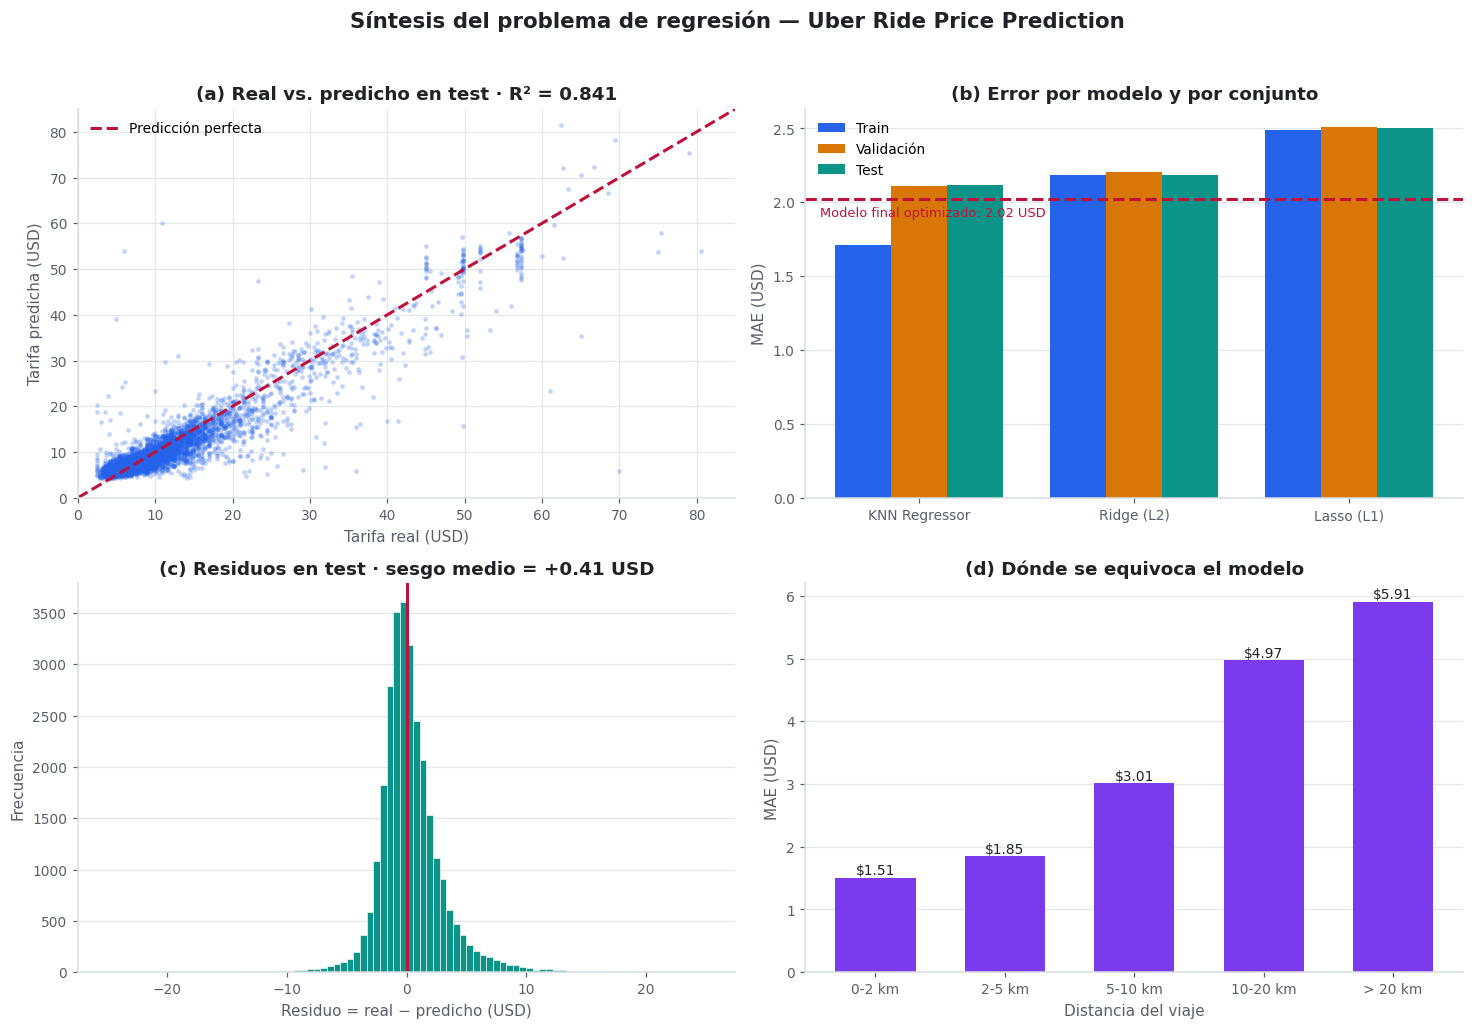

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5))
fig.suptitle("Síntesis del problema de regresión — Uber Ride Price Prediction",
             fontsize=14, fontweight="bold", color=TINTA, y=0.98)

# (1,1) Real vs. predicho del modelo final
ax = axes[0, 0]
idx = np.random.default_rng(RANDOM_STATE).choice(len(y_test), size=min(6000, len(y_test)), replace=False)
ax.scatter(y_test.values[idx], y_pred_test_final[idx], s=9, alpha=0.28, color=PALETA[0], linewidths=0)
lim = [0, 85]
ax.plot(lim, lim, color=PALETA[3], linewidth=2, linestyle="--", label="Predicción perfecta")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Tarifa real (USD)"); ax.set_ylabel("Tarifa predicha (USD)")
ax.set_title(f"(a) Real vs. predicho en test · R² = {metricas_finales['R2']:.3f}")
ax.legend(loc="upper left")

# (1,2) MAE por modelo y por conjunto
ax = axes[0, 1]
nombres = list(modelos.keys()); x = np.arange(len(nombres)); w = 0.26
v_tr = [tabla_fase5.loc[n, ("MAE", "Train")] for n in nombres]
v_va = [tabla_fase5.loc[n, ("MAE", "Validación")] for n in nombres]
v_te = [tabla_test.loc[n, "MAE"] for n in nombres]
ax.bar(x - w, v_tr, w, label="Train", color=PALETA[0])
ax.bar(x,     v_va, w, label="Validación", color=PALETA[1])
ax.bar(x + w, v_te, w, label="Test", color=PALETA[2])
ax.axhline(metricas_finales["MAE"], color=PALETA[3], linewidth=2, linestyle="--")
ax.text(-0.46, metricas_finales["MAE"] - 0.05, f"Modelo final optimizado: {metricas_finales['MAE']:.2f} USD",
        color=PALETA[3], fontsize=8.5, va="top", ha="left")
ax.set_xticks(x); ax.set_xticklabels(nombres, fontsize=9)
ax.set_ylabel("MAE (USD)"); ax.set_title("(b) Error por modelo y por conjunto")
ax.grid(axis="x", visible=False); ax.legend()

# (2,1) Distribución de residuos del modelo final
ax = axes[1, 0]
residuos = y_test.values - y_pred_test_final
ax.hist(residuos, bins=90, range=(-25, 25), color=PALETA[2], edgecolor="white", linewidth=0.4)
ax.axvline(0, color=PALETA[3], linewidth=2)
ax.set_xlabel("Residuo = real − predicho (USD)"); ax.set_ylabel("Frecuencia")
ax.set_title(f"(c) Residuos en test · sesgo medio = {residuos.mean():+.2f} USD")
ax.grid(axis="x", visible=False)

# (2,2) Error absoluto medio por tramo de distancia
ax = axes[1, 1]
tramos = pd.cut(X_test["distancia_km"], bins=[0, 2, 5, 10, 20, 150],
                labels=["0-2 km", "2-5 km", "5-10 km", "10-20 km", "> 20 km"])
err = pd.DataFrame({"tramo": tramos.values, "err": np.abs(residuos)}).groupby("tramo", observed=True)["err"].mean()
ax.bar(err.index.astype(str), err.values, color=PALETA[4], width=0.62)
for xi, v in zip(err.index.astype(str), err.values):
    ax.text(xi, v, f"${v:.2f}", ha="center", va="bottom", fontsize=9, color=TINTA)
ax.set_ylabel("MAE (USD)"); ax.set_xlabel("Distancia del viaje")
ax.set_title("(d) Dónde se equivoca el modelo")
ax.grid(axis="x", visible=False)

fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

### Conclusiones del problema de regresión

**Qué modelo funcionó mejor y por qué.** El **KNN Regressor optimizado** fue el mejor modelo, superando a Ridge
y Lasso en MAE, MSE y R² de forma consistente en validación y en test. La explicación está en la naturaleza del
fenómeno: la tarifa de un taxi en Nueva York **no es una función lineal global** de las variables, sino un
conjunto de **regímenes locales** — la tarifa plana a JFK, los corredores intra-Manhattan, los recargos
nocturnos. KNN, que predice promediando viajes geográficamente y temporalmente similares, reproduce esa
estructura de forma natural, mientras que Ridge y Lasso sólo pueden trazar un hiperplano y quedan atrapados en
un **régimen de alto sesgo (underfitting)**, visible en que su error en train y en validación es casi idéntico
y a la vez alto.

La gráfica (d) matiza el éxito y es probablemente el hallazgo más accionable del estudio: **el error crece casi
cuatro veces con la distancia** — de ~1.5 USD en los viajes de 0–2 km a ~5.9 USD en los de más de 20 km. Es
decir, el modelo es muy preciso en el viaje urbano típico (que es la inmensa mayoría) y notablemente menos
fiable en los trayectos largos, donde peajes, tráfico y *surge pricing* introducen variabilidad que las
variables disponibles no explican. La gráfica (c) añade un matiz en la misma dirección: los residuos están
centrados pero con un **sesgo medio positivo de ~0.4 USD**, es decir, el modelo **subestima ligeramente** las
tarifas en promedio, arrastrado por esa cola larga que nunca llega a predecir del todo.

El contraste entre los dos modelos lineales también es informativo: con el mismo `alpha = 1.0`, **Ridge mantuvo
todos sus coeficientes mientras Lasso anuló la mayoría**. Es la diferencia entre L2 (encoge los coeficientes
hacia cero sin eliminarlos) y L1 (los lleva exactamente a cero, haciendo selección de variables). Con sólo 24
features —ninguna claramente irrelevante— la selección agresiva de Lasso destruye información útil: L1 brilla
en alta dimensionalidad con muchas variables redundantes, no aquí.

**Qué limpieza fue más determinante.** Sin ninguna duda, **el filtrado geográfico y la construcción de
`distancia_km`**. Las coordenadas incluían valores imposibles (latitudes de 1 644°) que, de haberse conservado,
habrían dominado por completo cualquier escalamiento y habrían vuelto inútil la métrica de distancia de KNN.
Y la variable `distancia_km` —que no venía en el dataset— es el predictor con mayor correlación con el target (0.86). No se entrenó un modelo sólo con coordenadas crudas, pero un modelo lineal no puede *deducir* la fórmula de Haversine a partir de cuatro columnas de latitud/longitud. En segundo lugar, la decisión de **conservar los
outliers estadísticos con sentido de negocio** mientras se eliminaban los errores de captura: haber aplicado el
criterio IQR de forma mecánica habría eliminado el 8 % de los datos y, con ellos, todos los viajes a aeropuerto.

**Sobre el trade-off sesgo–varianza.** El experimento lo ilustra de punta a punta: KNN con `k=5` está en el
extremo de **alta varianza** (memoriza train, generaliza peor); Lasso con `alpha=1.0` está en el extremo de
**alto sesgo** (simplifica tanto que no aprende); y el modelo final —KNN con un número de vecinos varias veces
mayor, elegido por validación cruzada— se ubica en el punto intermedio, que es donde el error de generalización es mínimo. La escala también importó: KNN (distancias) y la penalización L1/L2 dependen de las unidades de las variables, por eso se aplicó `RobustScaler` (punto 10); y con ~24 features y ~135 000 observaciones KNN opera en un espacio denso, a diferencia del caso de tiroides.

**Limitaciones del estudio.**

1. **Variables ausentes clave.** No hay duración del viaje, condición de tráfico, clima, peajes ni multiplicador
   de *surge*. La dispersión residual de la gráfica (c) y el error creciente de la gráfica (d) son, en buena
   parte, la huella de esa información faltante.
2. **Distancia en línea recta.** Haversine ignora la red vial: un viaje entre Manhattan y Brooklyn recorre más
   kilómetros de los que mide la línea recta por la obligación de cruzar por un puente o túnel concreto.
3. **Vigencia temporal.** El modelo aprendió las tarifas de 2009–2015 y la gráfica de boxplots por año muestra
   una tendencia al alza; aplicarlo a años posteriores sin reentrenar produciría subestimaciones sistemáticas.
4. **Costo de inferencia.** El modelo ganador es el más caro de servir en producción, lo que en un sistema real
   podría inclinar la decisión hacia Ridge pese a su mayor error.
5. **Filtros con umbral elegido.** Los cortes (tarifa ≤ 250 USD, distancia ≤ 150 km, rectángulo de NYC) son
   decisiones razonadas pero discretas; otros umbrales darían resultados ligeramente distintos.

**Preguntas abiertas.** ¿Cuánto mejoraría el modelo con distancia de ruta real (API de rutas) y con datos de
tráfico? ¿Un modelo de ensamble basado en árboles (Random Forest / Gradient Boosting) capturaría los regímenes
locales tan bien como KNN pero con inferencia barata? ¿Conviene entrenar **modelos separados** para viajes de
aeropuerto y viajes urbanos, dado que son dos mecanismos de precio distintos? ¿Y modelar `log(fare_amount)`
para corregir la asimetría y la heterocedasticidad detectadas en el EDA?